In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.patches as patches

import numpy as np
import scipy.linalg


from tqdm import tqdm

import torch
from torch.utils.data import Subset

import torchvision.datasets
from torchvision import transforms

import pickle

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Réseau de Hopfield Classique

Le but est d'implémenter un réseau de Hopfield classique et de le tester sur 10 images différentes issues de MNIST (10 chiffres différents) afin de découvrir et d'expérimenter.

## Préparation des données
Récupération du jeu de données MNIST et conversion des valeurs des pixels en -1 lorsque le pixel vaut 0, et en 1 sinon, afin de correspondre au modèle d’Ising du réseau de Hopfield.

In [2]:
%matplotlib  inline

class ToSignedTensor:
    def __call__(self, x):
        x = transforms.ToTensor()(x)
        return torch.where(x == 0, -torch.ones_like(x), torch.ones_like(x))

dataSet = torchvision.datasets.MNIST(
    root="./data",
    download=True,
    transform=ToSignedTensor()
)

Extraction de 10 images différentes avec 10 chiffres différents de l'ensemble du data set

In [3]:
all_labels_np = dataSet.targets.numpy()
unique_labels, indices = np.unique(all_labels_np, return_index=True)
subset = Subset(dataSet, indices)
X = torch.stack([img.squeeze() for img, _ in subset])

Visualisation des 10 images extraites

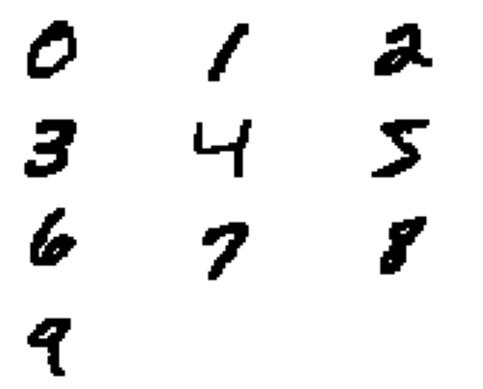

In [4]:
fig, axes = plt.subplots(4,3)
for i,image in enumerate(X):
    axes[i//3][i%3].imshow(image, cmap="binary")

for j in range(12):
    axes[j//3, j%3].axis('off')
plt.show()

## Création du Réseau
Création d'une classe implémentant les réseaux de Hopfield dans leur version de 1982

In [5]:
class HopfieldNetwork:
    def __init__(self, image_size, activation_function=torch.sign, order="sync", max_iter=300):
        self.image_size = image_size
        self.nb_neurones = image_size*image_size
        self.w_matrix = torch.zeros(self.nb_neurones, self.nb_neurones)
        
        if activation_function == torch.sign:
            self.activation_function = lambda x: torch.where(x>=0,1,-1)
        else:
            self.activation_function = activation_function
        
        self.order = order
        self.max_iter = max_iter
        self.train_data = None
        self.trained = False
    
    def train_Hebb(self, X, null_diagonal = True):
        self.train_data = X
        training_data = torch.reshape(X,[-1,self.nb_neurones]).float().to(DEVICE)
        self.w_matrix = (1 / self.nb_neurones) * (training_data.T @ training_data)
        if(null_diagonal):
            self.w_matrix.fill_diagonal_(0)
        self.trained = True
    
    def reset(self):
        self.w_matrix = torch.zeros(self.nb_neurones, self.nb_neurones)
        self.trained = False
        
    def get_w_matrix(self):
        return self.w_matrix.to("cpu")
    
    def get_training_data(self):
        if(self.trained):
            return self.train_data.to(DEVICE)
        else:
            return ValueError("Réseau non entrainer impossible de récupérer les données d'entrainement")
    
    def save(self,path_matrix='./w_matix.pt', path_training_data='./training_data.pt'):
        if(self.trained):
            torch.save(self.train_data, path_training_data)
        torch.save(self.w_matrix, path_matrix)
        
    def load(self,trained=False,path_matrix='./w_matix.pt', path_training_data='./training_data.pt'):
        if(trained):
            self.trained = trained
            self.train_data = torch.load(path_training_data).to(DEVICE)
        self.w_matrix = torch.load(path_matrix).to(DEVICE)
        
    def _calculate_energy(self, img, w_matrix):
        if img.device != self.w_matrix.device:
            img = img.reshape(-1, self.nb_neurones).float().to(DEVICE)    

        if img.shape[0] != self.nb_neurones:
            img = img.T 
    
        energies = -0.5 * torch.sum(img * (w_matrix @ img), dim=0) 
        return energies
    
    def calculate_energy(self, img):
        return self._calculate_energy(img, self.w_matrix)
    
    def resize_entry(self, entry):
        shape = entry.shape
        if(len(shape) < 3):
            entry = entry.unsqueeze(0)
            shape = entry.shape
        img = entry.reshape(-1,self.nb_neurones).float().to(DEVICE)
        img = img.transpose(0,-1)
        return img,shape

    def _apply(self, entry, w_matrix, equal=True):
        img, shape = self.resize_entry(entry)
        
        for iteration in range(self.max_iter):
            image_next = img.clone()
            
            if self.order == "async":
                indices = torch.randperm(self.nb_neurones, device=DEVICE)
                for i in range(self.nb_neurones):
                    idx = indices[i]
                    w_row = w_matrix[idx]
                    h_i = w_row @ image_next
                    new_val = self.activation_function(h_i)
                    image_next[idx] = new_val
            else:
                image_next = self.activation_function(w_matrix @ img).float()
           
            if equal and image_next.equal(img):
                break
    
            img = image_next
        
        energy = self._calculate_energy(img, w_matrix)
        img = img.transpose(0, -1)
        return img.reshape(-1, shape[-2], shape[-1]), energy
    
    def apply(self, entry):
        return self._apply(entry, self.w_matrix)

    def apply_with_trajectory(self, entry):
        img,shape = self.resize_entry(entry)
        trajectory = [img.clone()]
        energies = self.calculate_energy(img).unsqueeze(1)
        cycle = False          
        i=0
        while i<self.max_iter:
            image_next = img.clone()
            if self.order == "async":
                for idx in torch.randperm(self.nb_neurones):
                    h_i = self.w_matrix[idx] @ image_next
                    image_next[idx] = self.activation_function(h_i)
                    trajectory.append(image_next.clone())
                    energies = torch.cat([energies,self.calculate_energy(image_next).unsqueeze(1)], dim=1)
            else:
                image_next = self.activation_function(self.w_matrix @ img).float()
                trajectory.append(image_next.clone())
                energies = torch.cat([energies,self.calculate_energy(image_next).unsqueeze(1)], dim=1) 
                
            if image_next.equal(img):
                break
            
            if i > 1:

                traj_stack = torch.stack(trajectory, dim=0)
                comparison = (traj_stack == image_next)
                identical_images = comparison.all(dim=1)
                has_cycled_mask = identical_images.any(dim=0)
            
                if has_cycled_mask.any():
                    cycle = True
                    trajectory = trajectory[:-1]
                    energies = energies[:,:-1]
                    break
            img = image_next
            i = i+1

        trajectory = torch.stack(trajectory, dim=0).permute(2, 0, 1)
        img = img.transpose(0,-1)
        return img.reshape(-1, shape[-2], shape[-1]), trajectory.reshape(-1, trajectory.shape[1], shape[1], shape[2]), energies, cycle        
    
    def _test_number_pattern_unstable(self, dataset, w_matrix):
        result,_ = self._apply(dataset,w_matrix)
        result = result.reshape((-1,self.image_size,self.image_size))
        dataset = dataset.reshape((-1,self.image_size,self.image_size))
        hamming_result = distance_hamming(result,dataset)
        hamming_result = torch.where(hamming_result != 0, torch.ones_like(hamming_result), hamming_result)
        return hamming_result
    
    def test_number_pattern_unstable(self, dataset):
        return self._test_number_pattern_unstable(dataset,self.w_matrix)
        
    def benchmark(self, dataset, train=True, path=None, k_step=1):
        percentages = []
        if self.trained and train:
            print("Les poids du réseau vont être modifiés")
        for k in tqdm(range(1,len(dataset),k_step), desc="Calcul de la stabilité sur le data set"):
            if train:
                self.train_Hebb(dataset[:k])
            if k==1:
                percentages.append(self.test_number_pattern_unstable(dataset[:k]).sum().item()/k)
            else:
                percentages.append(self.test_number_pattern_unstable(dataset[:k]).diag().sum().item()/k)
        self.visualize_benchmark(percentages,path)
        
    def visualize_benchmark(self, percentages, path=None):
        plt.plot(torch.arange(1, len(percentages)+1), percentages)
        plt.xlabel("Nombre de patterns (k)")
        plt.ylabel("Fraction de patterns instables (%)")
        if max(percentages) > 0:
            plt.ylim(0, 1.05)
        plt.grid(True)
        if path is not None:
            plt.savefig(path)
        plt.show()

## Fonctions Utilitaires 

Implémentations de fonctions utilitaires comme une fonction permettant de calculer de la distance de Hamming entre 2 images 

In [6]:
def create_random_image(images=None, number=None, size=None, typed=torch.int8):
    if images is None and size is None:
        raise ValueError("Spécifier au moins 'images' ou 'size'")
    if images is not None:
        size = images.shape[-1]
    if number is not None and images is not None:
        images = images.repeat(number, 1, 1)
        number = images.shape[0]
    else:
        number = 1
    random_image = torch.randint(0,2,[number,size,size], dtype=typed)*2-1
    if images is not None:
        return torch.where(images==1, images, random_image)
    return  random_image
    

In [7]:
def distance_hamming(inputs, references):
    inputs = inputs.to(DEVICE)
    references = references.to(DEVICE)
    
    if references.dim() == 2 and references.shape[0] == references.shape[1] and references.shape[-1] == inputs.shape[-1]:
        references = references.flatten()
    if inputs.dim() == 2 and inputs.shape[0] == inputs.shape[1]:
        inputs = inputs.flatten()

    if inputs.dim() > 2:
        inputs = inputs.flatten(start_dim=1)
    if references.dim() > 2:
        references = references.flatten(start_dim=1)

    if inputs.dim() == 1: inputs = inputs.unsqueeze(0)
    if references.dim() == 1: references = references.unsqueeze(0)
    
    assert inputs.shape[1] == references.shape[1], \
        f"Erreur dimension neurones: {inputs.shape[1]} vs {references.shape[1]}"
    
    N_neurons = inputs.shape[1]
    dot_product = inputs @ references.T
    dist_normal = (N_neurons - dot_product) / 2
    dist_inverted = (N_neurons + dot_product) / 2 
    distances = torch.minimum(dist_normal, dist_inverted)
    
    return distances

In [8]:
def show_results(datas, network, targets=None, use_trajectory=False):
    n = len(datas)
    n_cols = 3 if targets is not None else 2
    fig, axes = plt.subplots(n, n_cols, figsize=(2 * n_cols, 2 * n))
    if n == 1:
        axes = [axes] 
    if use_trajectory:
        results, trajectories, energies, cycle = network.apply_with_trajectory(datas)
        energies = energies[:,-1]
    else: 
        results, energies = network.apply(datas)
        
    results = results.to("cpu")
    energies = energies.cpu()
    
    for i, image in enumerate(datas):
        if targets is not None:
            reference_image = targets[i]
            col_idx_output = 1
        else:
            reference_image = image
            col_idx_output = 0

        E = energies[i].item()
        D = distance_hamming(results[i], reference_image)
        
        print(f"Image {i} → Énergie : {E:.4f} | Hamming = {D.item()}")
        
        axes[i][col_idx_output].imshow(image, cmap="binary")
        axes[i][col_idx_output].axis("off")
        axes[i][col_idx_output].set_title(f"Entrée {i}")
        
        if targets is not None:
            axes[i][0].imshow(reference_image, cmap="binary")
            axes[i][0].axis("off")
            axes[i][0].set_title(f"Cible {i}")
        
        ax_out = axes[i][-1]
        ax_out.imshow(results[i], cmap="binary")
        ax_out.axis("off")
        ax_out.set_title(f"Sortie {i}\nÉnergie={E:.3f}\nHamming={D.item()}")

    plt.tight_layout()
    plt.show()

In [9]:
def bruitage_pixels_fixe(batch_images, nombre_pixels):
    if batch_images.dim() == 4:
        B, C, H, W = batch_images.shape
        total_pixels = C * H * W
        batch_flat = batch_images.view(B, -1)
    else:
        B, H, W = batch_images.shape
        total_pixels = H * W
        batch_flat = batch_images.flatten(1)

    device = batch_images.device

    if isinstance(nombre_pixels, int):
        if nombre_pixels > total_pixels:
            raise ValueError(f"Erreur: {nombre_pixels} > taille image ({total_pixels})")
            
        prob_map = torch.rand(B, total_pixels, device=device)
        _, indices = torch.topk(prob_map, k=nombre_pixels, dim=1)
        
        mask_flat = torch.zeros(B, total_pixels, device=device)
        mask_flat.scatter_(1, indices, 1)

    else:
        if not torch.is_tensor(nombre_pixels):
            nombre_pixels = torch.tensor(nombre_pixels, device=device)
        
        if nombre_pixels.dim() == 0:
             nombre_pixels = nombre_pixels.view(1).expand(B)
        
        if nombre_pixels.shape[0] != B:
            raise ValueError(f"Le tenseur nombre_pixels doit avoir la taille du batch ({B}), reçu {nombre_pixels.shape}")

        prob_map = torch.rand(B, total_pixels, device=device)
        pixel_ranks = prob_map.argsort(dim=1, descending=True).argsort(dim=1)
        mask_flat = (pixel_ranks < nombre_pixels.view(-1, 1)).float()
    mask = mask_flat.view_as(batch_images)
    images_bruites = torch.where(mask == 1, -batch_images, batch_images)

    return images_bruites

# Réseau entrainé sur 2 images

Extraction de deux images à partir d’un ensemble de 10 images, création de deux réseaux de Hopfield : l’un avec mise à jour asynchrone et l’autre avec mise à jour synchrone.
Entraînement des deux réseaux sur les deux images extraite du jeu de données.
Les premiers tests sont tous réaliser sur le réseau avec mise à jour synchrone.

In [14]:
X_train = X[[0,4]]

In [15]:
hopfield_network_sync = HopfieldNetwork(28, order="sync")
hopfield_network_sync.train_Hebb(X_train)

In [16]:
hopfield_network_async = HopfieldNetwork(28, order="async")
hopfield_network_async.train_Hebb(X_train)

Visualisation des résultats de l'application du réseau sur les deux images du dataset 

Image 0 → Énergie : -470.0203 | Hamming = 0.0
Image 1 → Énergie : -470.0203 | Hamming = 0.0


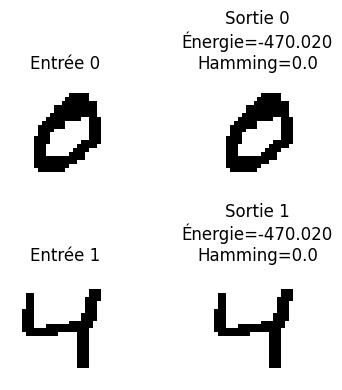

In [64]:
show_results(X_train, hopfield_network_sync)

Les deux images sont assez différentes et le réseau d'après les résultats théoriques peut sauvegarder jusqu'à 0.14*784 patterns différents soit environ 109 patterns différents.
Ainsi les résultats observés sont bien ceux attendus, et on a bien deux attracteurs qui sont les images d'entrainement.

On essaye maintenant sur l'ensemble des 10 images, on devrait avoir en sortie seulement les deux images utilisées pour l'entraînement. L'une ou l'autre en fonction de laquelle l'image passée en entrée est la plus proche

Image 0 → Énergie : -470.0202 | Hamming = 0.0
Image 1 → Énergie : -470.0202 | Hamming = 164.0
Image 2 → Énergie : -470.0202 | Hamming = 150.0
Image 3 → Énergie : -470.0202 | Hamming = 152.0
Image 4 → Énergie : -470.0202 | Hamming = 0.0
Image 5 → Énergie : -470.0202 | Hamming = 144.0
Image 6 → Énergie : -470.0202 | Hamming = 146.0
Image 7 → Énergie : -470.0202 | Hamming = 150.0
Image 8 → Énergie : -470.0202 | Hamming = 155.0
Image 9 → Énergie : -470.0202 | Hamming = 170.0


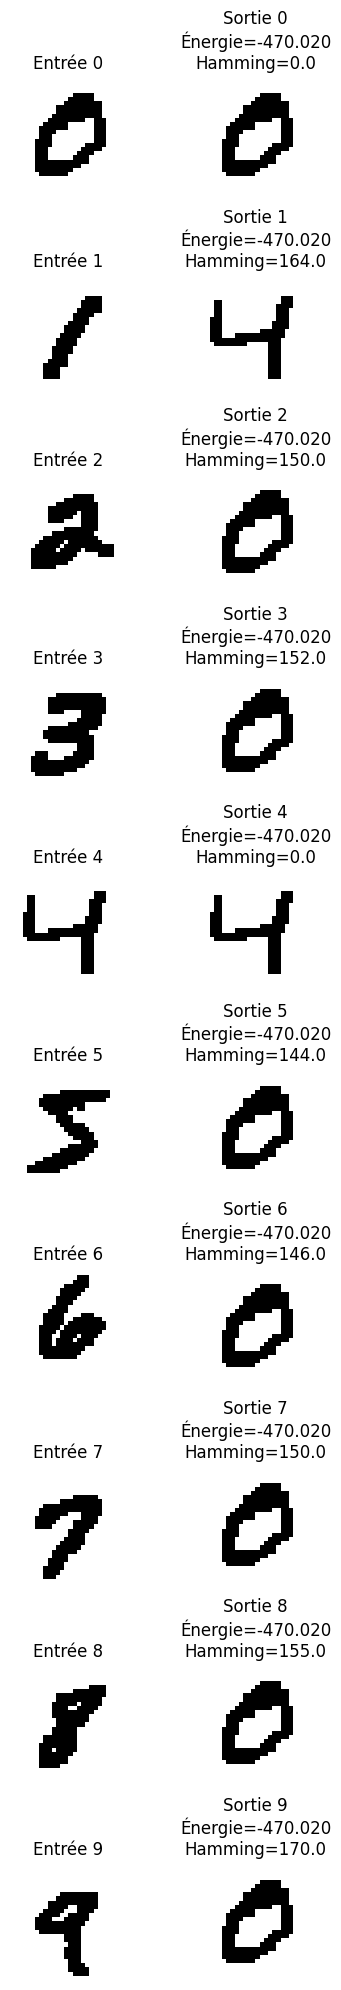

In [65]:
show_results(X, hopfield_network_sync)

Parmi les 10 images 8 sont relativement proche du 0 et 2 du 4. C'est d'ailleurs le résultat que l'on obtient en passant les 10 images dans le réseau, seul le 4 et le 1 atteignent 4 comme attracteur et tout les autres atteignent 0.

Essayons maintenant de bruité les deux images utilisées pour entrainer le réseau pour visualiser le résultat

Image 0 → Énergie : -470.0202 | Hamming = 326.0
Image 1 → Énergie : -470.0202 | Hamming = 344.0


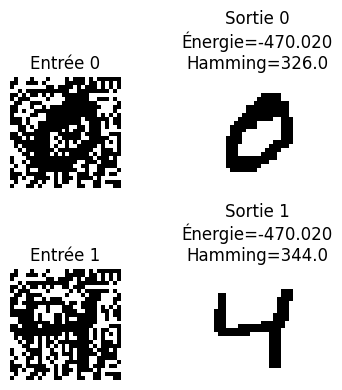

In [66]:
random_data = create_random_image(X_train)
show_results(random_data, hopfield_network_sync)

Nous allons maintenant essayer de bruiter l’image du chiffre 1, qui est reconnue comme l’image du 4 par le réseau, mais qui peut parfois être perçue comme un 0 selon le type de bruit ajouté.
Nous générons donc cinq images bruitées et les faisons passer dans le réseau afin d’observer les résultats.

Image 0 → Énergie : -470.0203 | Hamming = 364.0
Image 1 → Énergie : -470.0203 | Hamming = 364.0
Image 2 → Énergie : -470.0203 | Hamming = 356.0
Image 3 → Énergie : -470.0203 | Hamming = 358.0
Image 4 → Énergie : -470.0203 | Hamming = 360.0


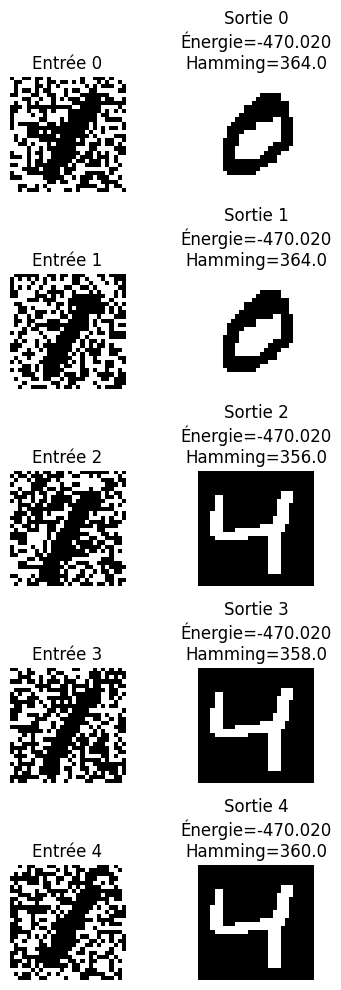

In [67]:
random_data = create_random_image(X[1],5)
show_results(random_data, hopfield_network_sync, True)

## Problème d'un réseau Synchrone
Dans le cas d'un réseau avec mise à jour synchrone on peut se retrouver avec l'apparition d'un cycle, c'est à dire que le réseau converge vers deux images différentes et cycle sur ces dernières.

Ici on va redonner l'image du 1 bruité aléatoirement au réseau et tenter de trouver un cycle puis il sera afficher 


Energy of image 0 0 : 0.954081654548645
Energy of image 1 0 : -58.510196685791016
Energy of image 2 0 : -58.510196685791016


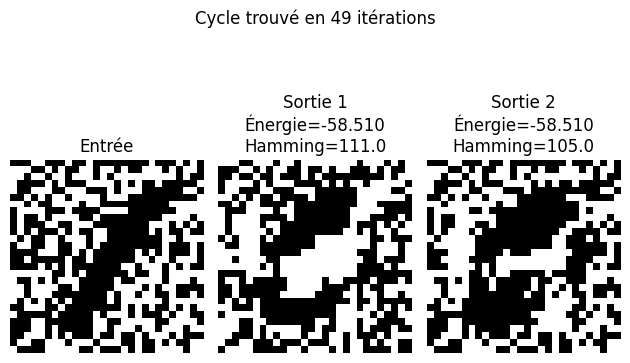

In [68]:
n=1
trajectory = []
cycle = False
k = 0
while not cycle:
    random_data = create_random_image(X[1],n)
    result, trajectory, energies, cycle = hopfield_network_sync.apply_with_trajectory(random_data)
    k = k + 1

trajectory = trajectory.cpu().numpy()

fig, axes = plt.subplots(n, len(trajectory[0]))
if n == 1:
    axes = [axes]
    

for i, list_image in enumerate(trajectory):
    for j, image in enumerate(list_image):
        E = energies[i][j].item()
        print(f"Energy of image {j} {i} : {energies[i][j].item()}")
        # Image d’entrée
        axes[i][j].imshow(image, cmap="binary")
        axes[i][j].axis("off")

        if j==0:
            axes[i][j].set_title("Entrée")
        else:
            D = distance_hamming(torch.from_numpy(image),random_data[i])
            axes[i][j].set_title(f"Sortie {j}\nÉnergie={E:.3f}\nHamming={D.item()}")
plt.suptitle(f"Cycle trouvé en {k} itérations")
plt.tight_layout()
plt.show()

Le résultat ici obtenu est que le réseau est tombé dans un cycle avec deux images de même énergie qui sont les deux sorties.

Nous allons maintenant réaliser la même expérience avec le réseau de Hopfield avec mise à jour asynchrone.

In [69]:
cycle = False
nb_images = 500

random_data = create_random_image(X[1].unsqueeze(0), nb_images)
result, trajectory, energies, cycle = hopfield_network_async.apply_with_trajectory(random_data)

if(cycle):
    print("Cycle trouvé")
else:
    print(f"Aucun cycle trouvé en {nb_images} itérations")

Aucun cycle trouvé en 500 itérations


Ainsi le résultat obtenu est qu'avec 150 images aléatoires différentes, il n'y a eu aucun cycle obtenu.
C'est dû au fait que la mise à jour est réalisé de manière asynchrone, cela empêche de tomber dans un cycle et garantie la convergence contrairement à la mise à jour synchrone qui ne garantie pas la convergence

## Visualisation des trajectoires énergétiques

Le but est maintenant d'observer les trajectoires énergétiques à partir de différentes images de départ, soit des combinaisons de bruit aléatoire et des 10 images extraites du dataset. Cela sera réalisé à la fois avec un réseau à mise à jour synchrone et un réseau à mise à jour asynchrone afin de retrouver le résultat précédent mais aussi d'observer la différence. Les images sont classifiées sur un axe via la projection de celles-ci, obtenue par une simple pondération des valeurs des pixels, et où les images symétriques sont définies par la même valeur.

Extraction de trois images du set de 10 images afin de visualiser les premier résultat d'un réseau de Hopfield

In [10]:
def projection_2D(img_tensor, refs=None):
    flat = ((img_tensor + 1) / 2).flatten()
    weights = torch.linspace(0, 1, steps=flat.numel())
    
    proj_normal = torch.dot(flat, weights).item()
    proj_inverse = torch.dot(1 - flat, weights).item()
    
    return min(proj_normal, proj_inverse)

def projection_hamming(img_tensor, refs, echelle=1.0):
    d_vers_0 = distance_hamming(img_tensor, refs[0])
    d_vers_500 = distance_hamming(img_tensor, refs[1])

    total_dist_relative = d_vers_0 + d_vers_500

    if total_dist_relative == 0:
        return 0.0
    position_normalisee = d_vers_0 / total_dist_relative
    
    return (position_normalisee * echelle).item()

def plot_energetic_landscape(images, hopfield_network, number_noisy=10, projection_function=projection_2D):
    training_data_set = hopfield_network.get_training_data()
    train_image_proj = [projection_function(image, training_data_set) for image in training_data_set]
    

    pattern_colors = ['#1f77b4', '#d62728']  
    parasite_color = '#7f7f7f'
    labels_seen = set()
    
    all_energies = []
    all_trajectories_projected = []

    for i, image in tqdm(enumerate(images), desc="Calcul des trajectoires"):
        random_data = create_random_image(image, number_noisy)
        result, trajectories, energies_batch, cycle = hopfield_network.apply_with_trajectory(random_data)
        
        for k in range(number_noisy):
            trajectory_k = trajectories[k].cpu()
            energies_k = energies_batch[k].cpu()
            
            all_energies.append(energies_k.tolist())
            projected_path = [projection_function(img, training_data_set) for img in trajectory_k]
            all_trajectories_projected.append(projected_path)
    
    plt.figure(figsize=(12, 7))
    
    for i in range(len(all_trajectories_projected)):
        path = all_trajectories_projected[i]
        energies = all_energies[i]
        final_proj = path[-1]
        
        assigned_color = parasite_color
        current_label = "État parasite"
        
        for j in range(len(train_image_proj)):
            if abs(final_proj - train_image_proj[j]) < 1e-5:
                assigned_color = pattern_colors[j] if j < len(pattern_colors) else plt.cm.tab10(j)
                current_label = f"Pattern {j+1}"
                break

        if current_label not in labels_seen:
            plt.plot(path, energies, color=assigned_color, alpha=0.6, 
                     label=current_label, linewidth=2, zorder=2 if "Pattern" in current_label else 1)
            labels_seen.add(current_label)
        else:
            plt.plot(path, energies, color=assigned_color, alpha=0.3, linewidth=1, zorder=1)

    plt.title("Paysage énergétique : Convergence vers les attracteurs", fontsize=14)
    plt.xlabel("Position sur l'axe de projection", fontsize=12)
    plt.ylabel("Énergie du réseau", fontsize=12)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title="Attracteurs finaux", frameon=True, shadow=True)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Calcul des trajectoires: 10it [01:28,  8.89s/it]


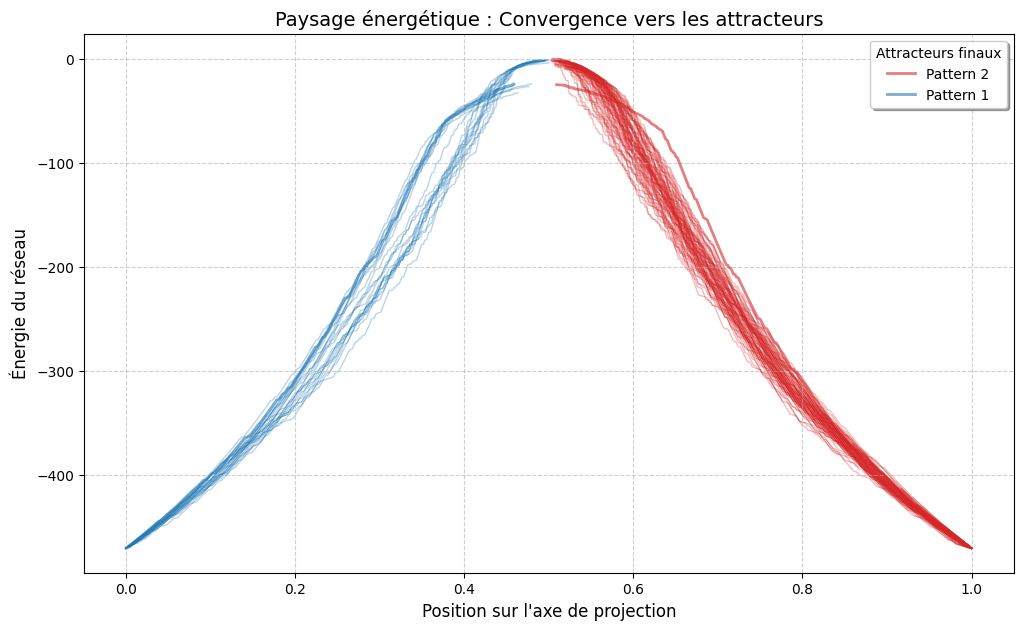

In [83]:
plot_energetic_landscape(X,hopfield_network_async,projection_function=projection_hamming)

Calcul des trajectoires: 10it [00:00, 40.30it/s]


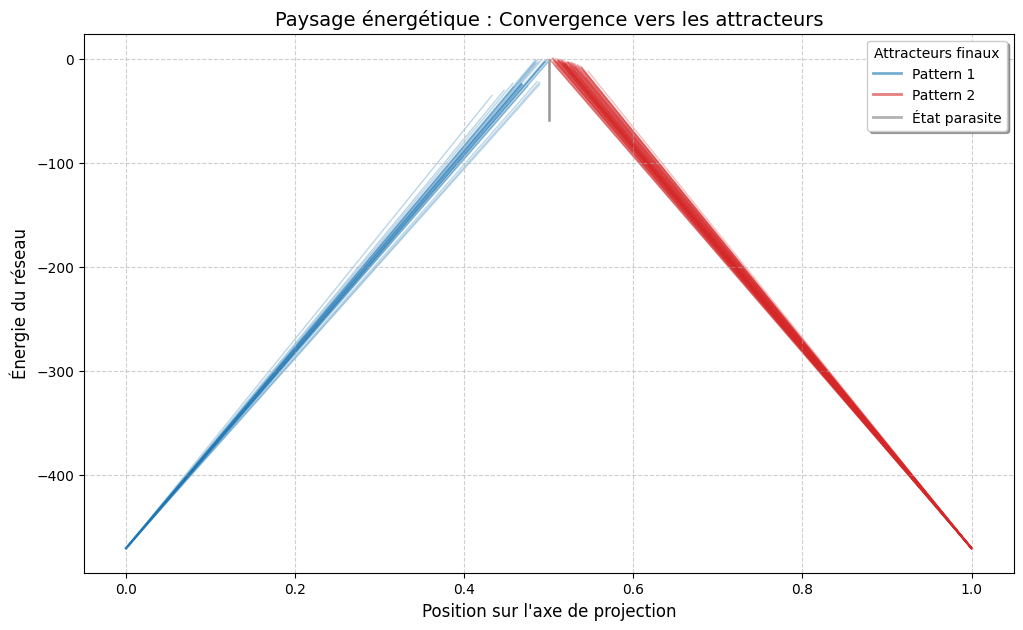

In [84]:
plot_energetic_landscape(X,hopfield_network_sync,projection_function=projection_hamming)

On retrouve le résultat défini précédemment. Dans le cas de la mise à jour synchrone, le réseau peut tomber dans un cycle de longueur supérieure à un, ce qui signifie que l'état final peut être différent des attracteurs d'entraînement. Or, avec une mise à jour asynchrone, le théorème de Lyapounov garantit que la fonction d'énergie est strictement décroissante à chaque étape. Par conséquent, l'état du réseau converge nécessairement vers un point fixe (un cycle de longueur un), et non vers un cycle plus long.

In [17]:
def make_gif_from_trajectory(trajectory, energies, input_image=None, filename="hopfield.gif", interval=200):
    n_cols = 3 if input_image is not None else 2
    fig, ax = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    
    idx_offset = 0
    if input_image is not None:
        ax[0].imshow(input_image, cmap='binary', vmin=-1, vmax=1)
        ax[0].set_title("Entrée bruitée")
        ax[0].axis("off")
        idx_offset = 1 

    ax_energy = ax[idx_offset]
    ax_energy.plot(np.arange(len(energies)), energies, color='tab:blue')
    point, = ax_energy.plot([0], [energies[0]], 'ro', label=f"E = {energies[0]:.2f}")
    ax_energy.set_xlabel("Itération")
    ax_energy.set_ylabel("Énergie")
    ax_energy.legend(loc="upper right")

    ax_recon = ax[idx_offset + 1]
    img_display = ax_recon.imshow(trajectory[0], cmap='binary', vmin=-1, vmax=1)
    ax_recon.set_title("Reconstruction")
    ax_recon.axis("off")

    def update(frame):
        point.set_data([frame], [energies[frame]])
        point.set_label(f"E = {energies[frame]:.2f}")
        ax_energy.legend(loc="upper right")
        
        img_display.set_data(trajectory[frame])
        fig.suptitle(f"Évolution temporelle - Étape {frame+1}")
        return [point, img_display]

    plt.tight_layout()

    ani = animation.FuncAnimation(fig, update, frames=len(trajectory),interval=interval, blit=False, repeat=False)

    ani.save(filename, writer="pillow")
    plt.close(fig)
    print(f"GIF sauvegardé sous {filename}")


In [18]:
random_image = bruitage_pixels_fixe(X[4].unsqueeze(0), nombre_pixels=100)
result, trajectory, energies , cycle = hopfield_network_async.apply_with_trajectory(random_image)
trajectory = trajectory[0].cpu().reshape(-1,28,28).numpy()
energies = energies[0].cpu().numpy()
make_gif_from_trajectory(trajectory, energies, interval=50, filename="hopfield_descent_classic.gif")

GIF sauvegardé sous hopfield_descent_classic.gif


In [87]:
n_digits = 10
n_noisy = 10

base_images = X[:n_digits]
noisy_images = create_random_image(base_images,n_noisy)

results, trajectories, energies, cycles = hopfield_network_async.apply_with_trajectory(noisy_images)

all_trajectories = trajectories.reshape(-1,28,28)
all_energies = energies.reshape(-1) 

all_trajectories, inverse_indices, counts = torch.unique(all_trajectories, dim=0, return_inverse=True, return_counts=True)

energies_filtered = torch.tensor([
    all_energies[(inverse_indices == i).nonzero(as_tuple=True)[0][0]]
    for i in range(len(all_trajectories))
], device=DEVICE)

print(f"Trajectoires uniques : {all_trajectories.shape}")

d1 = distance_hamming(all_trajectories,X_train[0]).cpu()
d2 = distance_hamming(all_trajectories,X_train[1]).cpu()

Trajectoires uniques : torch.Size([34409, 28, 28])


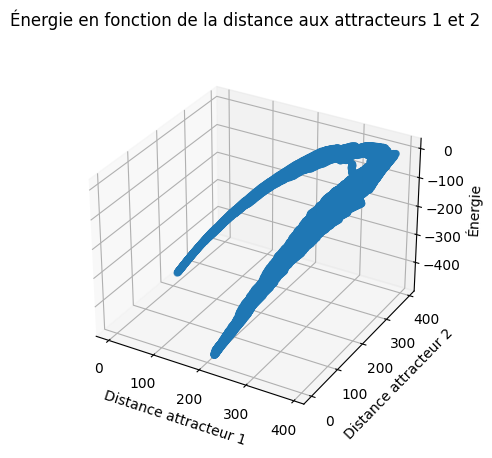

In [88]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(d1.numpy(),d2.numpy(),energies_filtered.cpu().numpy())
ax.set_xlabel("Distance attracteur 1")
ax.set_ylabel("Distance attracteur 2")
ax.set_zlabel("Énergie")
plt.suptitle("Énergie en fonction de la distance aux attracteurs 1 et 2")
plt.show()

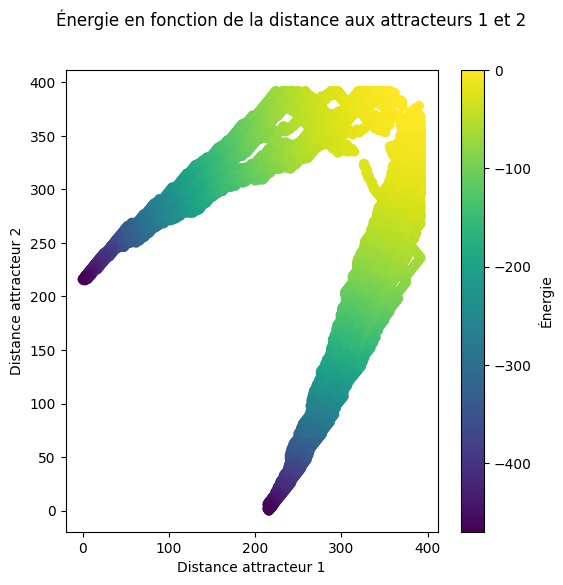

In [89]:
plt.figure(figsize=(6,6))
plt.scatter(d1.numpy(), d2.numpy(), c=energies_filtered.cpu().numpy(), cmap='viridis')
plt.colorbar(label='Énergie')
plt.xlabel("Distance attracteur 1")
plt.ylabel("Distance attracteur 2")
plt.suptitle("Énergie en fonction de la distance aux attracteurs 1 et 2")
plt.show()

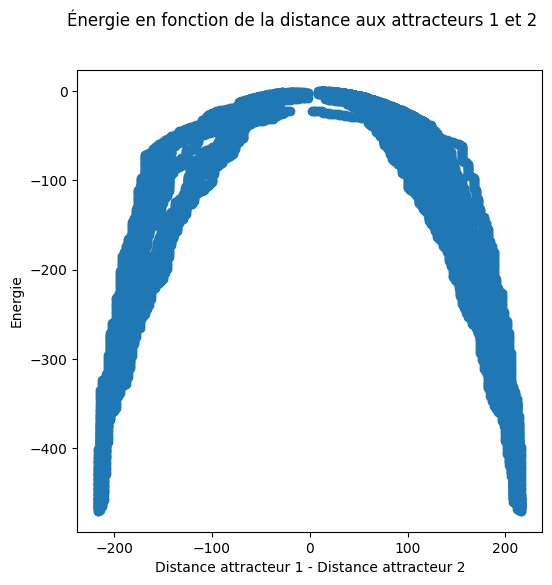

In [90]:
plt.figure(figsize=(6,6))
plt.scatter(d1.numpy()-d2.numpy(), energies_filtered.cpu().numpy())
plt.xlabel("Distance attracteur 1 - Distance attracteur 2")
plt.ylabel("Energie")
plt.suptitle("Énergie en fonction de la distance aux attracteurs 1 et 2")
plt.show()

# Réseau entrainé sur 3 images

Extraction de deux images à partir d’un ensemble de 10 images, création de deux réseaux de Hopfield : l’un avec mise à jour asynchrone et l’autre avec mise à jour synchrone.
Entraînement des deux réseaux sur les deux images extraite du jeu de données.
Les premiers tests sont tous réaliser sur le réseau avec mise à jour synchrone.

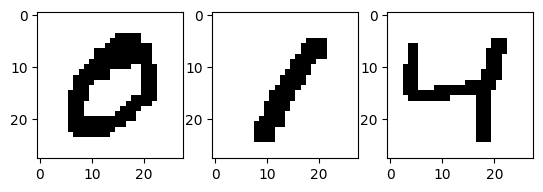

In [91]:
X_train_3Image = X[[0,1,4]]
fig, axes = plt.subplots(1,3)
for i,image in enumerate(X_train_3Image):
    axes[i%3].imshow(image, cmap="binary")
plt.show()

In [92]:
hopfield_network_3Images = HopfieldNetwork(28, order="async")
hopfield_network_3Images.train_Hebb(X_train_3Image)

Image 0 → Énergie : -584.1733 | Hamming = 0.0
Image 1 → Énergie : -684.7859 | Hamming = 64.0
Image 2 → Énergie : -684.7859 | Hamming = 100.0


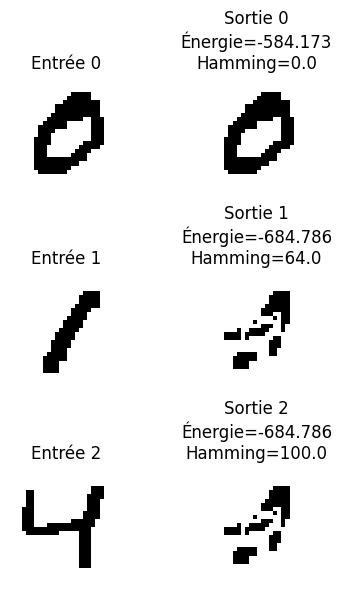

In [93]:
show_results(X_train_3Image,hopfield_network_3Images)

On peut voir qu'à partir de 3 motifs à mémorisés, le réseaux créer un état parasites avec 2 motifs d'entrainements proche l'un de l'autre (ici le 1 et le 4) qui converge vers un état parasite. cela vient du fait qu'ils sont fortement corrélés. Ainsi l'objectif est maintenant d'augmenter la capacité de stockage du réseau en utilisant des méthode qui peuvent s'apparentées au rêve biologique.

# Réseau de Hopfield avec Rêve

La classe suivant est une extension de la première qui implémente deux méthodes de rêve : le dé-apprentissage et la méthode du projecteur de matrice. Ces deux méthodes permettent d'augmenter la capacité de stockage du réseau en supprimant les états parasites.

In [19]:
class HopfieldNetworkDream(HopfieldNetwork):
    def __init__(self,image_size, epsilon=0.005, activation_function=torch.sign, order="sync", max_iter=30):
        super().__init__(image_size, activation_function, order, max_iter)
        self.epsilon = epsilon
    
    def _dreaming_unlearning(self, nb_image_random, w_matrices, alpha, beta):
        batch_size = w_matrices.shape[0]
        mask_diag = 1 - torch.eye(self.nb_neurones, device=w_matrices.device)
        w_matrices = w_matrices * mask_diag.unsqueeze(0)
    
        nb_iters = torch.tensor([
            max(1, int((self.nb_neurones / (self.epsilon * nb_image_random)) * (alpha * (k / self.nb_neurones)-beta)))
            for k in range(1,batch_size+1)
        ], device=w_matrices.device)
        max_iter = nb_iters.max().item()
        
        for iteration in tqdm(range(max_iter)):
            random_image = torch.randint(0, 2, [1, nb_image_random, self.nb_neurones], device=w_matrices.device).float() * 2 - 1
            random_image = random_image.expand(batch_size, -1, -1)
            results = self._apply_async_batch_w(random_image, w_matrices)
            correlation_terms = torch.einsum('bij,bik->bjk', results, results)
            correlation_matrices = (self.epsilon * correlation_terms) / (self.nb_neurones)
            update_mask = (iteration < nb_iters).float().view(batch_size, 1, 1)
            w_matrices = w_matrices - correlation_matrices * update_mask
            w_matrices = w_matrices * mask_diag.unsqueeze(0)
    
        return w_matrices

    def _apply_async_batch_w(self, entries, w_matrices):
        img = entries.clone()
        img_prev = torch.empty_like(img)
        
        for iteration in range(self.max_iter):
            img_prev.copy_(img)
            indices = torch.randperm(self.nb_neurones, device=w_matrices.device)
            for i in range(self.nb_neurones):
                idx = indices[i]
                w_rows = w_matrices[:, idx, :]
                h = torch.einsum('bin,bn->bi', img, w_rows)
                img[:, :, idx] = self.activation_function(h)
            if torch.equal(img, img_prev):
                break
        return img
            
    def dreaming_unlearning(self, nb_images, alpha=1.2, beta=0.05):
        self.w_matrix = self.w_matrix.unsqueeze(0)
        self.w_matrix = self._dreaming_unlearning(nb_images, self.w_matrix, alpha, beta).squeeze(0)

    def benchmark_unlearning(self, W_global, nb_image_random, alpha=1.2, beta=0.05):
        return self._dreaming_unlearning(nb_image_random,W_global, alpha, beta)
        
    def calculate_local_fields(self,image):
        return self.w_matrix@image.T
    
    def _dreaming_projector_matrix(self, nb_iter, W_global):      
        batch_size = W_global.shape[0]
        
        eigenvalues, _ = torch.linalg.eigh(W_global)
        epsilon_optimal = 0.90 / eigenvalues[:, -1]
        epsilons = epsilon_optimal.view(batch_size, 1, 1)
        
        for _ in tqdm(range(nb_iter), desc='Optimisation des matrices de poids W'):
            random_image = torch.randint(0, 2, [1, self.nb_neurones], dtype=torch.float, device=DEVICE) * 2 - 1
            random_image_batch = random_image.expand(batch_size, self.nb_neurones)
            
            random_image_batch = random_image_batch.unsqueeze(2).to(W_global.device)
            local_fields_batch = torch.bmm(W_global, random_image_batch)
            
            local_fields = local_fields_batch.squeeze(2)
            correlation_matrix_batch = torch.einsum('bi,bj->bij', local_fields, local_fields)
            dream_term = epsilons * correlation_matrix_batch / self.nb_neurones
            W_global = W_global - dream_term
        
        return W_global
            
    def dreaming_projector_matrix(self, nb_iter):
        self.train_data = self.resize_entry(self.train_data)[0].T
        self.w_matrix = torch.einsum("xi,xj -> xij", self.train_data, self.train_data).to(DEVICE)
        self.w_matrix = torch.sum(self.w_matrix,dim=0) / self.nb_neurones
        self.w_matrix = self._dreaming_projector_matrix(nb_iter, self.w_matrix.unsqueeze(0)).squeeze(0)
    
    def benchmark_projector_matrix(self, W_global , nb_iter):
        return  self._dreaming_projector_matrix(nb_iter,W_global)

        
    def benchmark_dream(self, dataset, path=None, method=None, **kwargs):
        if method is None:
            method = self.benchmark_unlearning

        if method not in [self.benchmark_unlearning, self.benchmark_projector_matrix]:
            raise ValueError(f"La méthode fournie n'est pas valide.")

        dataset, _ = self.resize_entry(dataset)
        dataset = dataset.T
        self.train_data = dataset    

        W_k = torch.einsum("xi,xj -> xij", dataset, dataset).to(DEVICE)           
        W_global = torch.cumsum(W_k, dim=0) / self.nb_neurones

        with torch.no_grad():
            W_global = method(W_global, **kwargs)
            self.w_matrix = W_global[-1].to(DEVICE)

        percentages = []
        for k in tqdm(range(1,len(dataset)+1), desc="Calcul de la stabilité sur le data set"):
            if k==1:
                percentages.append(self._test_number_pattern_unstable(dataset[:k],W_global[k-1]).sum().item()/k)
            else:
                percentages.append(self._test_number_pattern_unstable(dataset[:k],W_global[k-1]).diag().sum().item()/k)
        self.visualize_benchmark(percentages,path)

Optimisation des matrices de poids W: 100%|██████████| 1000/1000 [00:00<00:00, 2154.57it/s]


Image 0 → Énergie : -308.3529 | Hamming = 0.0
Image 1 → Énergie : -325.2460 | Hamming = 0.0
Image 2 → Énergie : -309.1565 | Hamming = 0.0


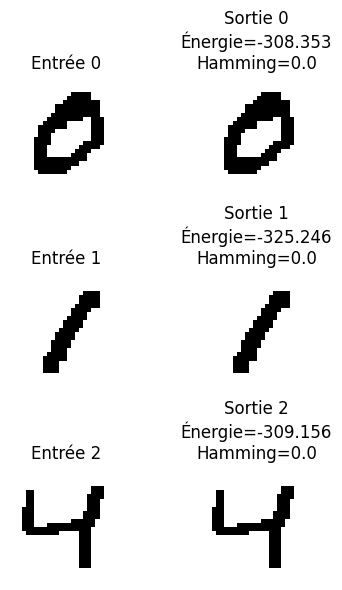

In [49]:
hopfield_network_3Images_projector_matrix = HopfieldNetworkDream(28, order="async")
hopfield_network_3Images_projector_matrix.train_Hebb(X_train_3Image)
hopfield_network_3Images_projector_matrix.dreaming_projector_matrix(1000)
show_results(X_train_3Image, hopfield_network_3Images_projector_matrix)

On peut voir que les deux méthodes de rêve permettent de récupérer les trois images d'entrainement, en supprimant l'état parasite qui apparaissait avec le réseau de Hopfield classique.
On va maintenant utiliser un autre dataset avec beaucoup plus de classes et donc potentiellement moins corrélées entre elles : ImageNet qui est composé de 1000 classes différentes. On va importer une version avec une image de chaque classes avec chaque images au format 16x16.

# Observation des capacités des différents réseaux avec ImageNet

## Observation sur le dataset ImageNet 16x16
Importation du jeu de données ImageNet, qui contient de nombreuses images réparties en 1000 classes différentes. Les images sont importées aux formats 16x16. Le dataset final sera constitué d'une seule image par classe afin d'assurer une diversité maximale (ou d'éviter toute corrélation).

In [14]:
def importImageNet(path,image_size):
    with open(path, 'rb') as fo:
        ImageNet= pickle.load(fo)
        
    labels = np.array(ImageNet["labels"])
    unique_labels, indices = np.unique(labels, return_index=True)
    indices = np.array(indices)
    
    datas = torch.from_numpy(np.array(ImageNet["data"], dtype=np.float32)[indices])
    datas = datas.reshape(len(indices), 3, image_size, image_size)
    grayscale_datas = datas.mean(axis=1)
    threshold = 255/2
    return torch.where(grayscale_datas > threshold, torch.ones_like(grayscale_datas), -torch.ones_like(grayscale_datas))

def extractIndependant(dataset):
    dataset_flat = dataset.reshape([-1, 16*16]) 
    matrice_calcul = dataset_flat.T.cpu().numpy()
    Q, R, P = scipy.linalg.qr(matrice_calcul, pivoting=True)
    tol = 1e-5
    rang = np.sum(np.abs(np.diag(R)) > tol)
    indices_independants = P[:rang]
    return dataset[np.sort(indices_independants)]

imageNet_16x16 = importImageNet("./data/Imagenet16_val/val_data",16)
imageNet_16x16_indep = extractIndependant(imageNet_16x16)

Les futurs tests du réseau de Hopfield s'effectueront sur un jeu de données de 1000 images au format 16x16. Par conséquent, le réseau sera dimensionné à 256 neurones (16×16). Un second dataset est créer qui est une version réduite du premier, ne contenant que 256 images linéairement indépendantes entre elles.

Pour le benchmark du réseau de base, la théorie prévoit le stockage stable de 0.14×256 images (soit 35 images) si celles-ci sont non corrélées. Ici le benchmark est réalisé sur le réseau entrainé avec 0 à 50 images car nous observons que seuls 4 patterns au maximum sont mémorisés de façon stable. Ainsi il n'était pas intéressant d'assayer de stocker les 1000 images.

Calcul de la stabilité sur le data set: 100%|██████████| 99/99 [00:47<00:00,  2.11it/s]


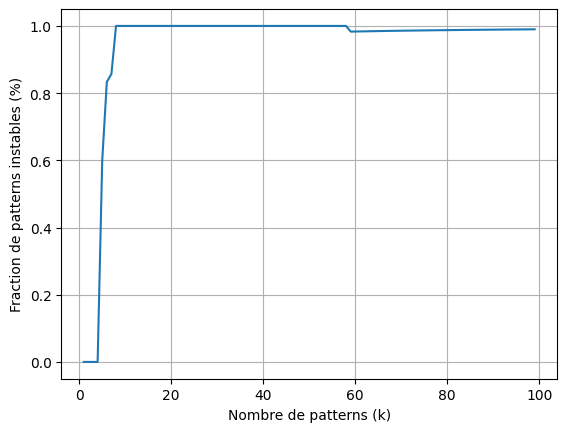

In [13]:
network_base_16x16 = HopfieldNetwork(16, order="async", max_iter=10)
network_base_16x16.benchmark(imageNet_16x16[:100])

Calcul de la stabilité sur le data set: 100%|██████████| 99/99 [01:07<00:00,  1.47it/s]


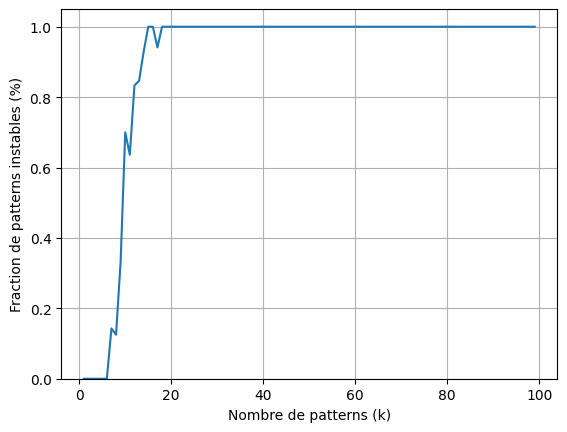

In [15]:
network_base_16x16 = HopfieldNetwork(16, order="async", max_iter=10)
network_base_16x16.benchmark(imageNet_16x16_indep[:100])

Concernant le benchmark intégrant le processus d'« unlearning » (désapprentissage), la capacité théorique pour des données non corrélées est de 0.68×256, soit 174 images. Bien que nous n'atteignions ici que 6 patterns stables, on voit que contrairement au réseau de base sans unlearning qui se confronte à un mur à partir de 8 patterns plus aucun patterns n'est stable. Alors qu'avec l'unlearning, plus aucun des patterns d'entrainements ne sont stables qu'à partir de 30.

Calcul de la stabilité sur le data set: 100%|██████████| 100/100 [00:47<00:00,  2.13it/s]


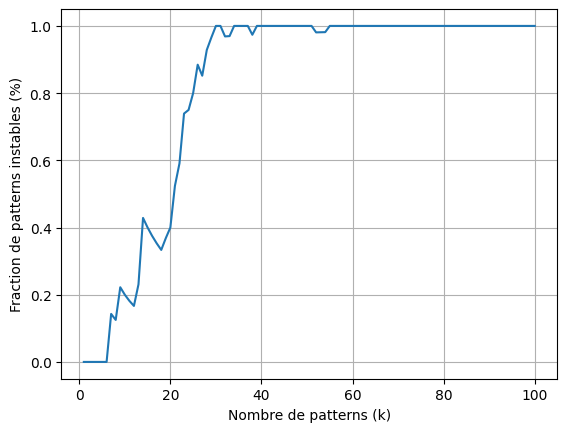

In [16]:
network_unlearning_16x16 = HopfieldNetworkDream(16, order="async", max_iter=10)
network_unlearning_16x16.benchmark_dream(imageNet_16x16[:100], None,method=network_unlearning_16x16.benchmark_unlearning,nb_image_random=10, alpha=0.48, beta=0)

Calcul de la stabilité sur le data set: 100%|██████████| 100/100 [00:33<00:00,  2.97it/s]


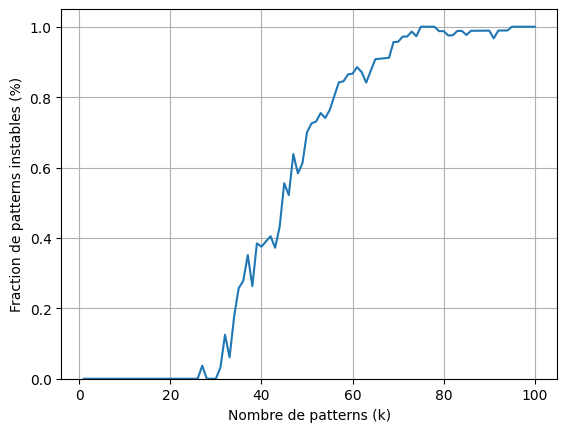

In [17]:
network_unlearning_16x16 = HopfieldNetworkDream(16, order="async", max_iter=10)
network_unlearning_16x16.benchmark_dream(imageNet_16x16_indep[:100], None,method=network_unlearning_16x16.benchmark_unlearning,nb_image_random=10, alpha=0.48, beta=0)

Ce benchmark évalue le processus de « Dreaming », qui vise à converger vers la matrice de projection. La capacité théorique atteint ici 1×N (soit 256 images), ce qui est 7 fois supérieur au modèle de base et environ 1,5 fois supérieur au modèle avec unlearning. En pratique, le réseau parvient à mémoriser 58 images stables. Cette performance dépasse les attentes par rapport aux réseaux précédents : c'est plus de 7 fois le score du réseau de base et plus de 2 fois celui du réseau avec unlearning. Mais cela reste largement en dessous de la limite théorique.

Calcul de la stabilité sur le data set: 100%|██████████| 256/256 [00:40<00:00,  6.37it/s]


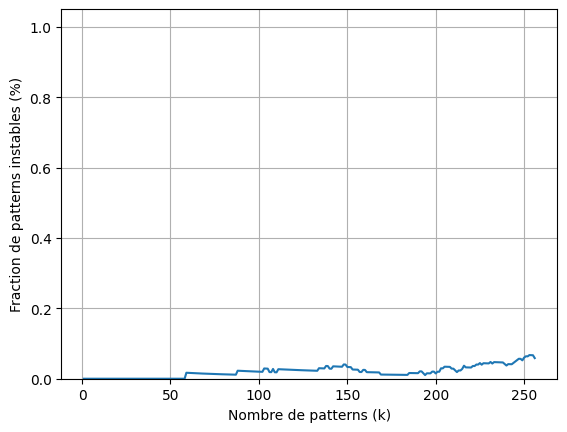

In [18]:
network_projector_16x16 = HopfieldNetworkDream(16, order="async", max_iter=10)
network_projector_16x16.benchmark_dream(imageNet_16x16[:256],None, method=network_projector_16x16.benchmark_projector_matrix,nb_iter=50000)

Calcul de la stabilité sur le data set: 100%|██████████| 256/256 [00:13<00:00, 18.90it/s]


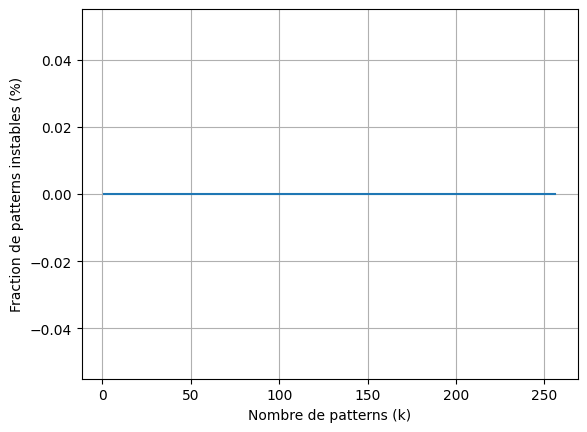

In [96]:
network_projector_16x16_indep = HopfieldNetworkDream(16, order="async", max_iter=10)
network_projector_16x16_indep.benchmark_dream(imageNet_16x16_indep,None, method=network_projector_16x16_indep.benchmark_projector_matrix,nb_iter=50000)

# Observation sur un dataset décorrélé
Nous reproduisons les mêmes benchmarks, mais cette fois sur un jeu de données réduit contenant uniquement 256 images non corrélées. Car le principal problème était que les images sont corrélées entre elles, ce qui diminue fortement la capacité de stockage du réseau dans le cas du réseau de base et de la méthode d'unlearning. Dans le cas de la matrice projecteur le problème était que les images n'était pas linéairement indépendantes.


In [99]:
non_correlee = torch.randint(0,2,[256,16,16],dtype=torch.float,device=DEVICE)*2-1

## Analyse de la corrélation des images du dataset
Les fonctions suivantes permettent  de calculer et d'afficher les statistiques de corrélation entre les images d'un jeu de données. Elles calculent la matrice de corrélation, puis extraient des statistiques telles que la corrélation maximale et la moyenne absolue des corrélations hors diagonale. Enfin, elles affichent ces statistiques et une visualisation de la matrice de corrélation.

Cela permet de voir que le jeu de donnée initiale est en partie corrélé, tandis que le jeu de donnée non corrélé l'est très peu.

In [12]:
def compute_pattern_correlation(patterns):
    P, N = patterns.shape
    patterns_centered = patterns - patterns.mean(dim=1, keepdim=True) 
    std = patterns_centered.std(dim=1, keepdim=True)
    patterns_normalized = patterns_centered / (std + 1e-8) 
    corr_matrix = (patterns_normalized @ patterns_normalized.T) / N
    
    mask = 1 - torch.eye(P, device=patterns.device)
    off_diag_corr = corr_matrix * mask
    correlations = torch.abs(off_diag_corr[mask.bool()])
    
    stats = {
        'max': correlations.max().item(),             
        'abs_mean': correlations.abs().mean().item(), 
        'corr_matrix': off_diag_corr.cpu().numpy(),      
    }
    
    return stats


def analyze_dataset_correlation(patterns, plot=True):    
    stats = compute_pattern_correlation(patterns)
    
    print(f"\n--- Statistiques de corrélation ---")
    print(f"Max:               {stats['max']:7.4f}")
    print(f"Moyenne |corr|:    {stats['abs_mean']:7.4f}")
    
    # Interprétation
    print(f"\n--- Interprétation ---")
    if stats['abs_mean'] < 0.1:
        print("Patterns TRÈS PEU CORRÉLÉS (quasi-aléatoires)")
    elif stats['abs_mean'] < 0.3:
        print("Patterns MODÉRÉMENT CORRÉLÉS")
    else:
        print("Patterns FORTEMENT CORRÉLÉS")
    
    if plot:
        fig, axes = plt.subplots(1, 1, figsize=(16, 4))

        im = axes.imshow(stats['corr_matrix'], cmap='Purples', vmin=0, vmax=1, aspect='auto')
        axes.set_xlabel('Pattern index')
        axes.set_ylabel('Pattern index')
        axes.set_title('Matrice de corrélation')
        plt.colorbar(im, ax=axes)

        plt.tight_layout()
        plt.show()


--- Statistiques de corrélation ---
Max:                0.9419
Moyenne |corr|:     0.1332

--- Interprétation ---
Patterns MODÉRÉMENT CORRÉLÉS


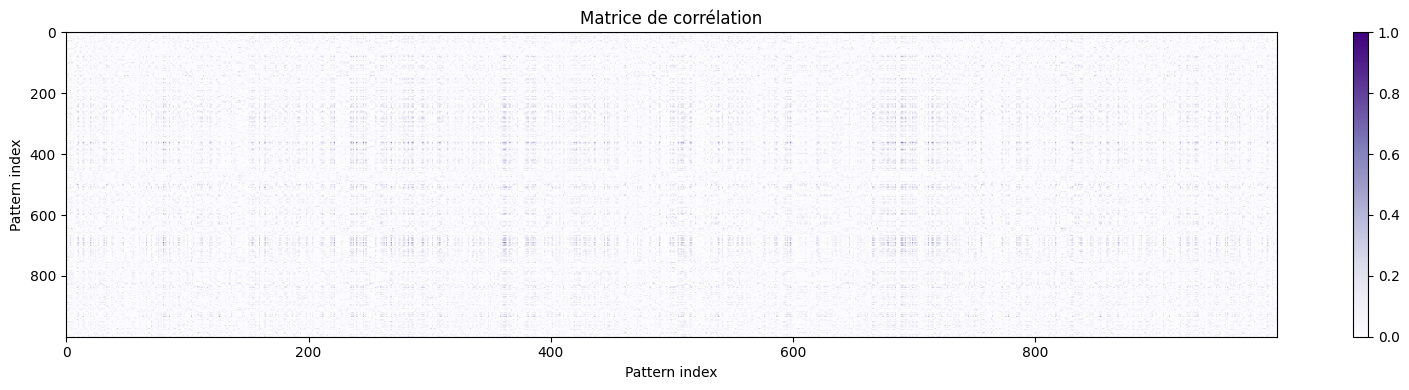

In [43]:
analyze_dataset_correlation(imageNet_16x16.reshape([-1,16*16]))


--- Statistiques de corrélation ---
Max:                0.2675
Moyenne |corr|:     0.0500

--- Interprétation ---
Patterns TRÈS PEU CORRÉLÉS (quasi-aléatoires)


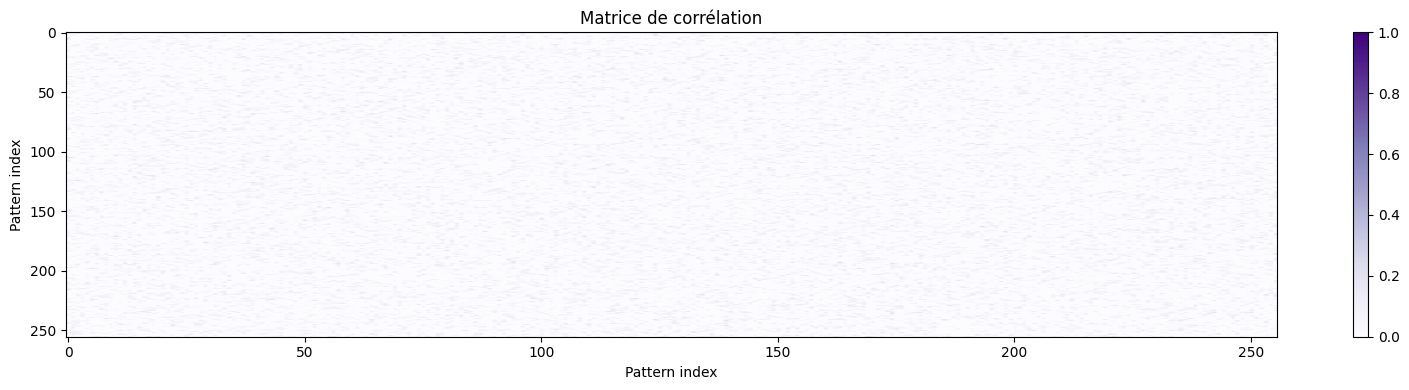

In [44]:
analyze_dataset_correlation(non_correlee.reshape([-1,256]))

## Résultats sur le dataset décorrélé

Ce benchmark est réalisé sur un jeu de données de 256 images non corrélées. Pour le réseau de base, la capacité théorique est de 0.14×256 (soit 35 images). Ici, le réseau parvient à mémoriser 21 images stables, ce qui est plus proche de la limite théorique qu'avec des images corrélées. 

Calcul de la stabilité sur le data set: 100%|██████████| 99/99 [00:45<00:00,  2.16it/s]


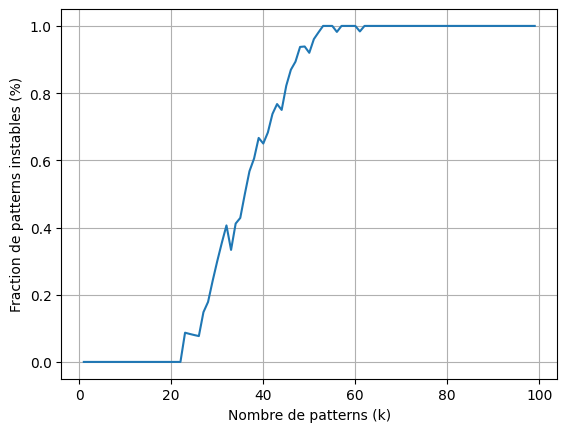

In [33]:
network_base_non_correlee= HopfieldNetwork(16, order="async", max_iter=10)
network_base_non_correlee.benchmark(non_correlee[:100])

Avec la méthode de l'unlearning, on obtient un résultat d'environ 170 images stables, ce qui est proche de la limite théorique de 0.68×256 (soit 174 images). Cela confirme que la méthode d'unlearning est efficace pour augmenter la capacité de stockage du réseau lorsque les images sont non corrélées. 

Calcul de la stabilité sur le data set: 100%|██████████| 256/256 [00:50<00:00,  5.11it/s]


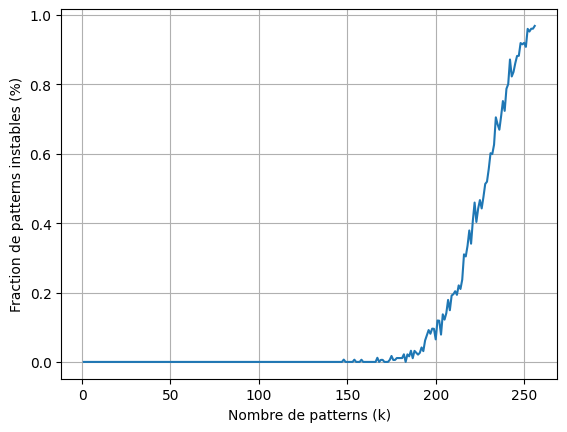

In [35]:
network_unlearning_non_correlee = HopfieldNetworkDream(16, order="async", max_iter=10)
network_unlearning_non_correlee.benchmark_dream(non_correlee[:256], None,method=network_unlearning_non_correlee.benchmark_unlearning,nb_image_random=100)

Enfin, lorsque les images sont non corrélées, elles sont également linéairement indépendantes. Ainsi, la méthode de la matrice projecteur fonctionne correctement. Comme on le constate, on atteint la limite théorique de 256 images stables, comme dans le cas des images linéairement indépendantes observé précédemment.

Calcul de la stabilité sur le data set: 100%|██████████| 256/256 [00:14<00:00, 17.38it/s]


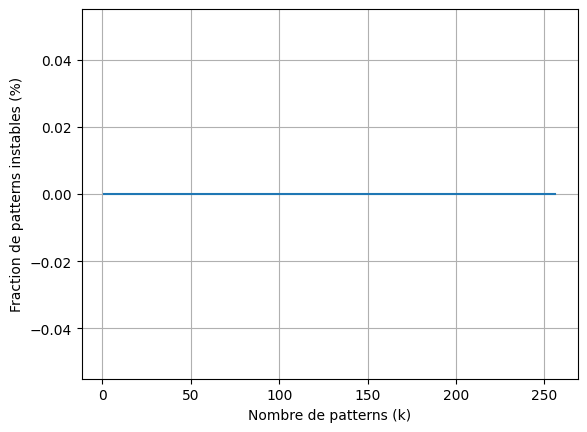

In [100]:
network = HopfieldNetworkDream(16, order="async", max_iter=10)
network.benchmark_dream(non_correlee, None, network.benchmark_projector_matrix, nb_iter=30000)

# Réseau de Hopfield Moderne

L'objectif est d'implémenter un **réseau de Hopfield moderne**, également appelé **Dense Associative Memory (DAM)**. Ce concept, proposé par Hopfield et Krotov en 2016, permet d'augmenter significativement la capacité de stockage du réseau en utilisant des fonctions d'énergie non linéaires, contrastant avec le modèle quadratique classique.

Pour ce faire, nous devons réimplémenter plusieurs méthodes de la classe `HopfieldNetwork`, notamment la fonction de mise à jour. En effet, là où le modèle classique repose sur une matrice de poids calculée après entraînement, les réseaux modernes stockent directement les motifs (*patterns*) à sauvegarder et les utilisent explicitement lors des calculs de dynamique du réseau.

Ici, comme pour le réseau classique, nous utiliserons d'abord le jeu de données **MNIST** puis le jeu de données **ImageNet** et enfin un jeu de données non corrélées afin de réaliser les différentes expérimentations.

In [23]:
class HopfieldNetworkModern(HopfieldNetwork):
    def __init__(self, image_size, activation_function=torch.sign, f=lambda x: torch.pow(x, 2), max_iter=30, images = None):
        super().__init__(image_size, activation_function, "async", max_iter)   
        
        if images is not None:
            self.set_training_data(images)
        else:
            self.train_data = None
            self.trained = False
            
        self.application_function_f = f
    
    def set_training_data(self, X):
        self.train_data = torch.reshape(X,[-1,self.nb_neurones]).float().to(DEVICE)
        self.trained = True
        
    def _calculate_energy(self, img):
        img, shape = self.resize_entry(img)
        datas = self.get_training_data()
        return -torch.sum(self.application_function_f(datas @ img), dim=0)
    
    def resize_entry(self, entry):
        shape = entry.shape
        if len(shape) < 3 and shape[-1] != self.nb_neurones:
            entry = entry.unsqueeze(0)
            shape = entry.shape
        img = entry.reshape(-1,self.nb_neurones).float().to(DEVICE)
        img = img.transpose(0,-1)
        return img,shape

    def _apply(self, entry, equal=True):
        img, shape = self.resize_entry(entry)
        training_datas = self.get_training_data()        
        for iteration in range(self.max_iter):
            image_next = img.clone()
            indices = torch.randperm(self.nb_neurones, device=DEVICE)
            
            for i in range(self.nb_neurones):
                idx = indices[i]
                res_total = training_datas @ image_next
                res_index =  training_datas[:, idx].view(-1, 1) @ image_next[idx,:].view(1, -1)
                result_function_application = self.application_function_f(training_datas[:, idx].view(-1, 1)+res_total-res_index)
                result_function_application_neg = self.application_function_f(-training_datas[:, idx].view(-1, 1)+res_total-res_index)
                result = self.activation_function(torch.sum(result_function_application-result_function_application_neg, dim=0))
                image_next[idx] = result

            if equal and image_next.equal(img):
                break
    
            img = image_next
        
        energy = self._calculate_energy(img)
        img = img.transpose(0, -1)
        return img.reshape(-1, shape[-2], shape[-1]), energy
    
    def apply(self, entry):
        return self._apply(entry)

    def _calculate_energy(self, img, w_matrix=None):
        if img.device != self.train_data.device:
                img = img.to(self.train_data.device)
        
        if img.dim() == 1:
            img = img.unsqueeze(1)

        dot_product = torch.matmul(self.train_data, img)
        f_values = self.application_function_f(dot_product) 
        return -torch.sum(f_values)
            
    def calculate_energy(self, img):
        return self._calculate_energy(img, self.w_matrix)

    def apply_with_trajectory(self, entry):
        img,shape = self.resize_entry(entry)
        trajectory = [img.clone()]
        energies = self.calculate_energy(img).reshape(1, 1)
        cycle = False          
        i=0
        training_datas = self.get_training_data()

        while i<self.max_iter:
            image_next = img.clone()
            for idx in torch.randperm(self.nb_neurones):
                
                res_total = training_datas @ image_next
                res_index =  training_datas[:, idx].view(-1, 1) @ image_next[idx,:].view(1, -1)
                result_function_application = self.application_function_f(training_datas[:, idx].view(-1, 1)+res_total-res_index)
                result_function_application_neg = self.application_function_f(-training_datas[:, idx].view(-1, 1)+res_total-res_index)
                result = self.activation_function(torch.sum(result_function_application-result_function_application_neg, dim=0))
                image_next[idx] = result
                        
                trajectory.append(image_next.clone())
                energies = torch.cat([energies,self.calculate_energy(image_next).reshape(1, 1)], dim=1)
                
            if image_next.equal(img):
                break
            
            if i > 1:
                traj_stack = torch.stack(trajectory, dim=0)
                comparison = (traj_stack == image_next)
                identical_images = comparison.all(dim=1)
                has_cycled_mask = identical_images.any(dim=0)
            
                if has_cycled_mask.any():
                    cycle = True
                    trajectory = trajectory[:-1]
                    energies = energies[:,:-1]
                    break
                    
            img = image_next
            i = i+1

        trajectory = torch.stack(trajectory, dim=0).permute(2, 0, 1)
        img = img.transpose(0,-1)
        return img.reshape(-1, shape[-2], shape[-1]), trajectory.reshape(-1, trajectory.shape[1], shape[1], shape[2]), energies, cycle        
    
    def _test_number_pattern_unstable(self, test_dataset, train_dataset=None):
        result, _ = self._apply(test_dataset)
        
        if train_dataset is None:
            dataset = self.get_training_data()
        else:
            dataset = train_dataset
    
        hamming_matrix = distance_hamming(result, dataset)
        n_inputs = hamming_matrix.shape[0]
        n_targets = hamming_matrix.shape[1]
        
        if n_inputs % n_targets != 0:
            raise ValueError(f"Erreur: Inputs ({n_inputs}) n'est pas un multiple de Targets ({n_targets})")
            
        n_levels = n_inputs // n_targets
        dists_3d = hamming_matrix.view(n_levels, n_targets, n_targets)
        relevant_distances = dists_3d.diagonal(dim1=1, dim2=2) 
        failures = torch.where(relevant_distances != 0, torch.ones_like(relevant_distances), relevant_distances)
        return failures.flatten()
    
    def test_number_pattern_unstable(self, test_dataset, train_dataset = None):
        return self._test_number_pattern_unstable(test_dataset, train_dataset)
        
    def benchmark(self, dataset, train=True, path=None, k_step=1):
        percentages = []
        for k in tqdm(range(1,len(dataset), k_step), desc="Calcul de la stabilité sur le data set"):
            if train:
                self.set_training_data(dataset[:k])
            if k==1:
                percentages.append(self.test_number_pattern_unstable(dataset[:k]).sum().item()/k)
            else:
                percentages.append(self.test_number_pattern_unstable(dataset[:k]).diag().sum().item()/k)
        self.visualize_benchmark(percentages,path)

    def benchmark_noise_robustness(self, dataset, 
                                   max_size_batch=50000, 
                                   noise_step=15, 
                                   k_step=1, k_start=2, k_end=None, 
                                   noise_start=0, noise_end=None, 
                                   vectorized_mode=True):

        N = self.nb_neurones
        
        if noise_end is None: noise_end = N // 2
        noise_levels = np.linspace(noise_start, noise_end, noise_step, dtype=np.int32)
        num_levels = len(noise_levels)
        
        batch_per_level = int(max_size_batch // num_levels)
        
        if batch_per_level < 10:
            print(f"⚠️ Attention : Budget trop faible pour {num_levels} niveaux. Force à 10 img/lvl.")
            batch_per_level = 10
            
        if k_end is None: k_end = len(dataset)
        k_values = list(range(k_start, k_end, k_step))
        if len(dataset) not in k_values and len(dataset) <= k_end: k_values.append(len(dataset))
            
        global_matrix = [] 

        print(f"Taille globale du batch : {max_size_batch} ops")
        print(f"Résolution    : {num_levels} niveaux de bruit")
        
        dataset = dataset.float().to(DEVICE)
        torch.no_grad()
        for k in tqdm(k_values, desc="Progression (K)"):
            current_train_data = dataset[:k]
            self.set_training_data(current_train_data)
            
            # On tire au hasard 'batch_per_level' images PAR NIVEAU
            # Note : On n'a besoin que d'un seul set d'indices de base
            indices = torch.randint(0, k, (batch_per_level,), device=DEVICE)
            targets_base = current_train_data[indices] 
            
            error_rates_for_this_k = []

            if vectorized_mode:
                targets_full = targets_base.repeat(num_levels, 1, 1)
                noise_vals = torch.tensor(noise_levels, device=DEVICE).repeat_interleave(batch_per_level)
                noisy_full = bruitage_pixels_fixe(targets_full.clone(), noise_vals)

                reconstructed_full, _ = self._apply(noisy_full, equal=True)

                reconstructed_reshaped = reconstructed_full.reshape(num_levels, batch_per_level, -1)
                targets_reshaped = targets_full.reshape(num_levels, batch_per_level, -1)
                
                dot_product = torch.einsum('lbn,lbn->lb', reconstructed_reshaped, targets_reshaped)
                
                N = self.nb_neurones
                dist_h = (N - dot_product) / 2
                dist_h_inv = (N + dot_product) / 2
                min_dist_h = torch.minimum(dist_h, dist_h_inv)
                seuil_erreur = 0
                success_mask = min_dist_h <= seuil_erreur
                
                accuracies = success_mask.float().mean(dim=1)
                error_rates_for_this_k = ((1.0 - accuracies) * 100).cpu().tolist()
                mean_hamming_dist = min_dist_h.mean(dim=1).cpu().tolist()
            else:
                for nb_noise in noise_levels:
                    noise_tensor = torch.full((batch_per_level,), nb_noise, device=DEVICE)
                    noisy_batch = bruitage_pixels_fixe(targets_base.clone(), noise_tensor)
                    reconstructed, _ = self._apply(noisy_batch, equal=True)
                    reconstructed = reconstructed.reshape(targets_base.shape)
                    equality_mask = torch.all(torch.eq(torch.sign(reconstructed), torch.sign(targets_base)), dim=1)
                    acc = equality_mask.sum().item() / batch_per_level
                    error_rates_for_this_k.append((1.0 - acc) * 100)
            
            global_matrix.append(error_rates_for_this_k)
        
        self.visualize_noise_robustness(np.array(global_matrix), k_values, noise_levels)
        return np.array(global_matrix), k_values, noise_levels


    def visualize_noise_robustness(self, matrix, k_values, noise_levels, path=None):
        noise_min, noise_max = min(noise_levels), max(noise_levels)
        y_limit = self.nb_neurones // 2
        k_min, k_max = min(k_values), max(k_values)
        full_y_range = np.arange(0, y_limit + 1)
        full_matrix = np.zeros((len(full_y_range), len(k_values)))
    
        for i, y in enumerate(full_y_range):
            if y < noise_min:
                full_matrix[i, :] = matrix[:, 0]
            elif y > noise_max:
                full_matrix[i, :] = matrix[:, -1]
            else:
                idx = np.abs(np.array(noise_levels) - y).argmin()
                full_matrix[i, :] = matrix[:, idx]
    
        plt.figure(figsize=(10, 6))
        cmap = 'RdYlGn_r'
        
        img = plt.imshow(full_matrix, cmap=cmap, vmin=0, vmax=100, aspect='auto',
                         extent=[k_min, k_max, 0, y_limit], 
                         interpolation='nearest', origin='lower')
        
        plt.axhline(y=noise_min, color='black', linestyle='-', linewidth=1.5, alpha=0.8, label='Zone calculée')
        plt.axhline(y=noise_max, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
    
        plt.colorbar(img, label='Taux d\'erreur (%)')
        plt.xlabel("Nombre de patterns stockés (k)")
        plt.ylabel("Niveau de bruit (pixels inversés)")
        plt.title(f"Analyse énergétique : Taille du bassins d'attraction")
        plt.legend(loc='upper right')
        
        if path is not None:
            plt.savefig(path)
        plt.show()

## Résultat sur MNIST
L'objectif est de vérifier que les résultats obtenus sur le dataset MNIST avec le réseau de Hopfield moderne sont cohérents avec ceux du réseau classique pour 2 motifs sauvegardés. Ensuite, nous allons utiliser un réseau avec une fonction d'énergie de la forme $x^4$ pour apprendre 3 motifs différents. Là où le réseau classique commençait à montrer des difficultés, ce modèle est censé être plus performant.

In [108]:
hopfield_network_modern = HopfieldNetworkModern(28, f=lambda x: torch.pow(x,2), max_iter=10, images=X_train)

Image 0 → Énergie : -201064.0000 | Hamming = 0.0
Image 1 → Énergie : -184840.0000 | Hamming = 0.0


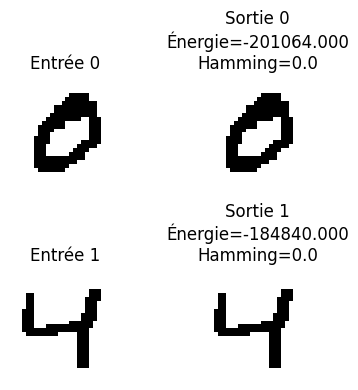

In [109]:
show_results(X_train, hopfield_network_modern)

Image 0 → Énergie : -482560.0000 | Hamming = 0.0
Image 1 → Énergie : -315472.0000 | Hamming = 164.0
Image 2 → Énergie : -117640.0000 | Hamming = 150.0
Image 3 → Énergie : -16456.0000 | Hamming = 152.0
Image 4 → Énergie : -69776.0000 | Hamming = 0.0
Image 5 → Énergie : -50216.0000 | Hamming = 144.0
Image 6 → Énergie : -146536.0000 | Hamming = 146.0
Image 7 → Énergie : -58312.0000 | Hamming = 150.0
Image 8 → Énergie : -257896.0000 | Hamming = 155.0
Image 9 → Énergie : -482560.0000 | Hamming = 170.0


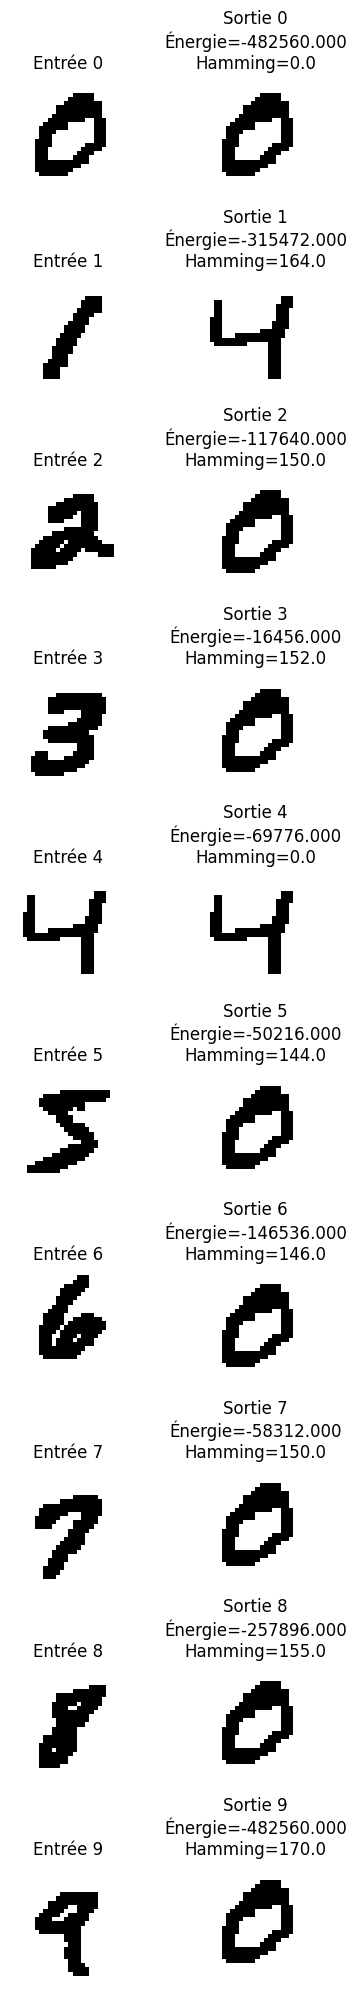

In [110]:
show_results(X, hopfield_network_modern)

Image 0 → Énergie : -201064.0000 | Hamming = 302.0
Image 1 → Énergie : -184840.0000 | Hamming = 341.0


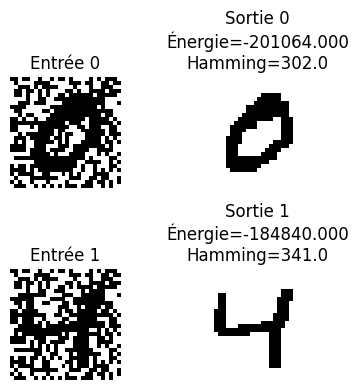

In [111]:
random_data = create_random_image(X_train)
show_results(random_data, hopfield_network_modern)

On observer bien les même résultats que pour le réseau de Hopfield classique, ce qui était attendu.

Image 0 → Énergie : -90735001600.0000 | Hamming = 0.0
Image 1 → Énergie : -11500490752.0000 | Hamming = 0.0
Image 2 → Énergie : -69071560704.0000 | Hamming = 0.0


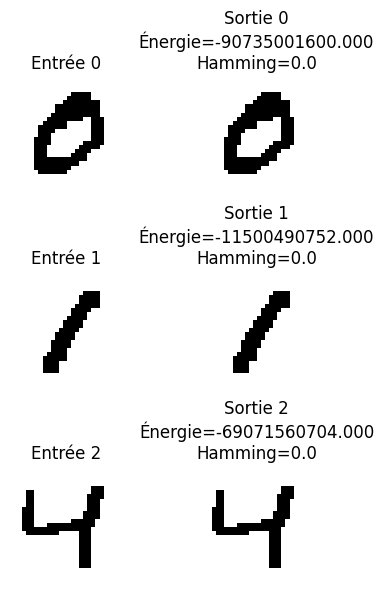

In [113]:
hopfield_network_modern_3Images = HopfieldNetworkModern(28, f=lambda x: torch.pow(x,4), max_iter=10, images=X_train_3Image)
show_results(X_train_3Image, hopfield_network_modern_3Images)

Image 0 → Énergie : -90735001600.0000 | Hamming = 319.0
Image 1 → Énergie : -11500490752.0000 | Hamming = 361.0
Image 2 → Énergie : -69071560704.0000 | Hamming = 337.0


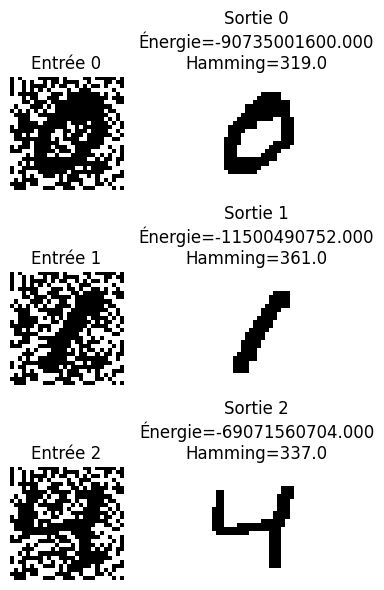

In [114]:
random_data = create_random_image(X_train_3Image)
show_results(random_data, hopfield_network_modern_3Images)

On constate que le réseau parvient à récupérer parfaitement ces 4 motifs, même si ces derniers sont encore visibles bien qu'entourés de bruit.

## Résultats sur ImageNet
Nous allons maintenant réaliser des benchmarks sur le réseau de Hopfield moderne avec le dataset ImageNet, qui est plus complexe que MNIST. Nous allons tester différentes fonctions d'énergie pour observer leur impact sur les performances du réseau.

Calcul de la stabilité sur le data set: 100%|██████████| 99/99 [02:01<00:00,  1.22s/it]


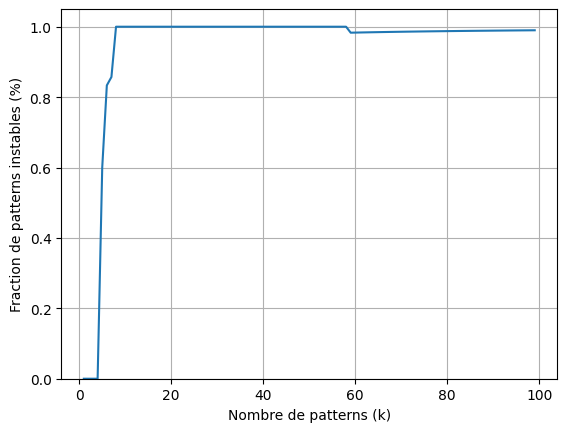

In [32]:
hopfield_network_modern_ImageNet_2 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x,2), max_iter=10)
hopfield_network_modern_ImageNet_2.benchmark(imageNet_16x16[:100])

Une fois de plus avec le réseau moderne équivalent au réseau classqiue, énergie de la forme $x^2$, on observe les mêmes résultats que pour le réseau de Hopfield classique.

--- BENCHMARK AUTO-SCALE ---
Budget Global : 5000 ops
Résolution    : 128 niveaux de bruit
Taille Batch  : 39 images par niveau
----------------------------


Progression (K): 100%|██████████| 49/49 [01:14<00:00,  1.53s/it]


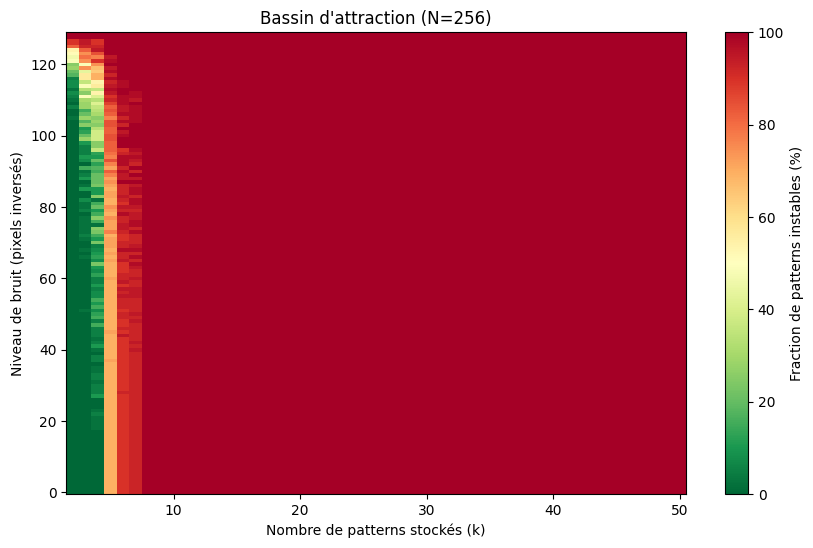

In [82]:
hopfield_network_modern_ImageNet_2.benchmark_noise_robustness(imageNet_16x16[:50], noise_step=128, max_size_batch=5000)

Calcul de la stabilité sur le data set: 100%|██████████| 255/255 [04:19<00:00,  1.02s/it]


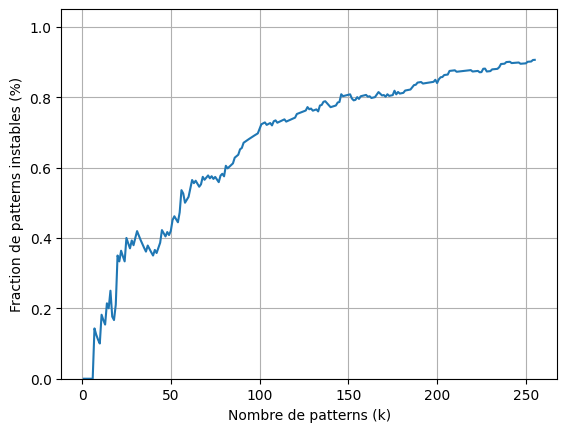

In [20]:
hopfield_network_modern_ImageNet_4 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x,4), max_iter=10)
hopfield_network_modern_ImageNet_4.benchmark(imageNet_16x16[:256])

On voit ici qu'avec une énergie de la forme $x^4$ l'évolution de la fraction de pattern instable en fonction du nombres de patterns qui ont été enrgistrés est plus lente que pour l'énergie de la forme $x^2$. Ce qui montre une amélioration avec l'augmentation de la puissance.

Analyse Robustesse (Vectorisée): 100%|██████████| 98/98 [02:34<00:00,  1.57s/it]


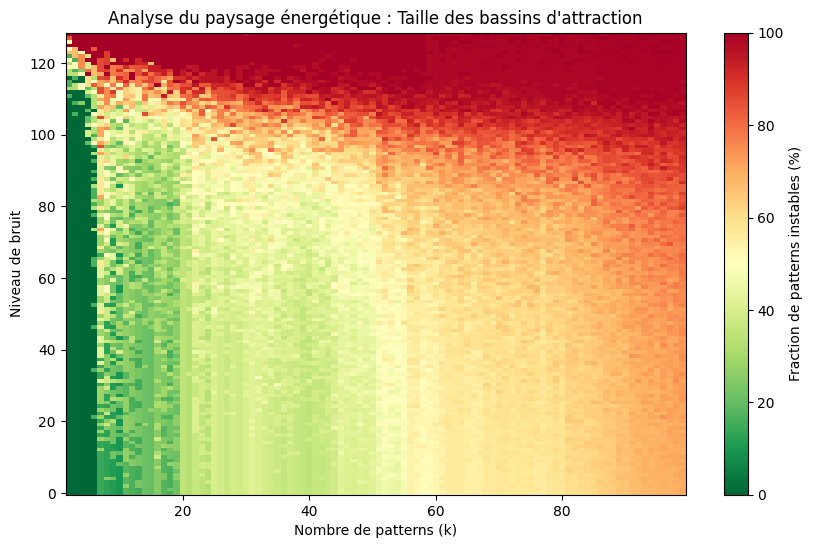

In [122]:
hopfield_network_modern_ImageNet_4.benchmark_noise_robustness(imageNet_16x16[:100], noise_step=128)

Calcul de la stabilité sur le data set: 100%|██████████| 255/255 [01:37<00:00,  2.60it/s]


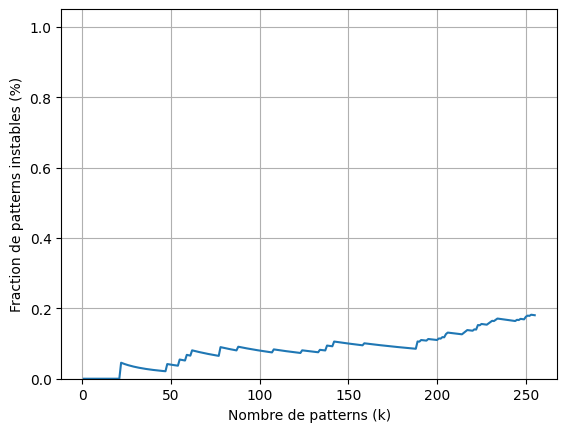

In [21]:
hopfield_network_modern_ImageNet_10 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 10), max_iter=10)
hopfield_network_modern_ImageNet_10.benchmark(imageNet_16x16[:256])

Avec une énergie de la forme $x^{10}$, on voit que le réseau parvient à mémoriser plus de 100 images de manière quasi stables, ce qui est une amélioration significative par rapport au réseau classique et au réseau moderne avec énergie de la forme $x^4$. Cela montre que l'augmentation de la puissance dans la fonction d'énergie permet d'améliorer considérablement les performances du réseau de Hopfield moderne.

Analyse Robustesse (Vectorisée):  39%|███▊      | 98/254 [01:45<02:10,  1.20it/s]

k=100 : 64 versions bruitées par pattern (Essais: 1 | Batch Total: 6400)


Analyse Robustesse (Vectorisée):  78%|███████▊  | 198/254 [04:10<01:54,  2.05s/it]

k=200 : 64 versions bruitées par pattern (Essais: 1 | Batch Total: 12800)


Analyse Robustesse (Vectorisée): 100%|██████████| 254/254 [07:04<00:00,  1.67s/it]


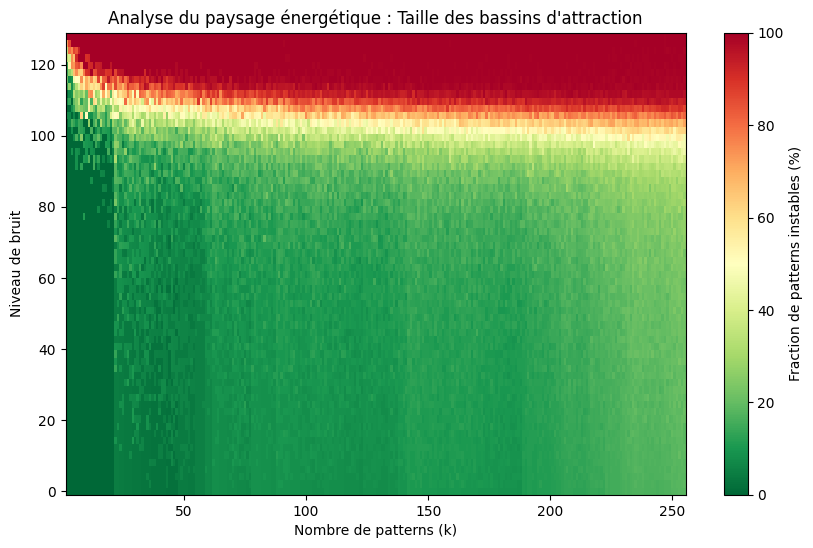

In [125]:
hopfield_network_modern_ImageNet_10.benchmark_noise_robustness(imageNet_16x16[:256], noise_step=64)

Calcul de la stabilité sur le data set: 100%|██████████| 255/255 [01:45<00:00,  2.42it/s]


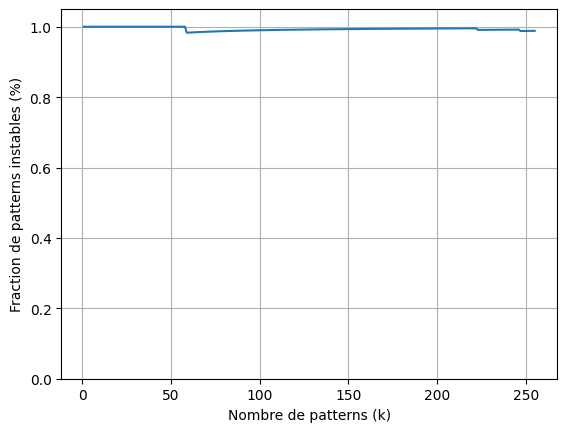

In [22]:
hopfield_network_modern_ImageNet_20 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 20), max_iter=10)
hopfield_network_modern_ImageNet_20.benchmark(imageNet_16x16[:256])

Analyse Robustesse (Vectorisée):  39%|███▊      | 98/254 [01:35<02:06,  1.23it/s]

k=100 : 64 versions bruitées par pattern (Essais: 1 | Batch Total: 6400)


Analyse Robustesse (Vectorisée):  78%|███████▊  | 198/254 [04:08<02:17,  2.46s/it]

k=200 : 64 versions bruitées par pattern (Essais: 1 | Batch Total: 12800)


Analyse Robustesse (Vectorisée): 100%|██████████| 254/254 [07:01<00:00,  1.66s/it]


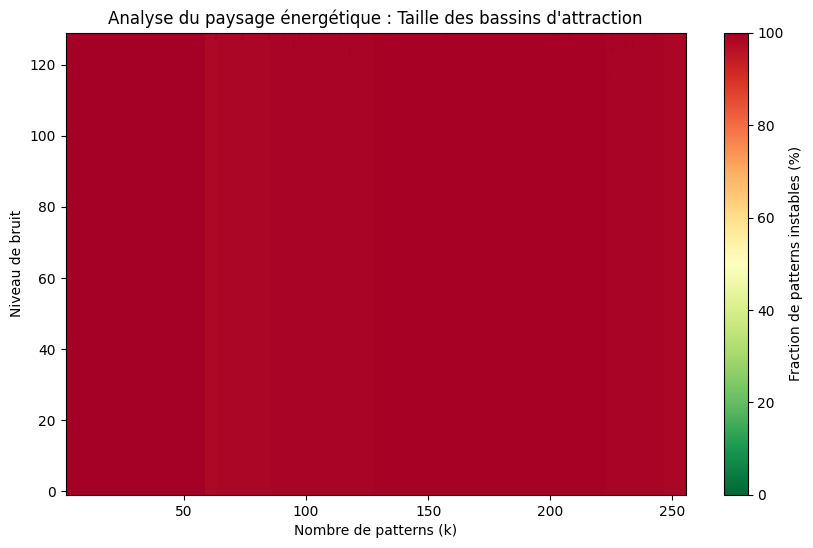

In [128]:
hopfield_network_modern_ImageNet_20.benchmark_noise_robustness(imageNet_16x16[:256], noise_step=64)

Calcul de la stabilité sur le data set: 100%|██████████| 255/255 [01:31<00:00,  2.79it/s]


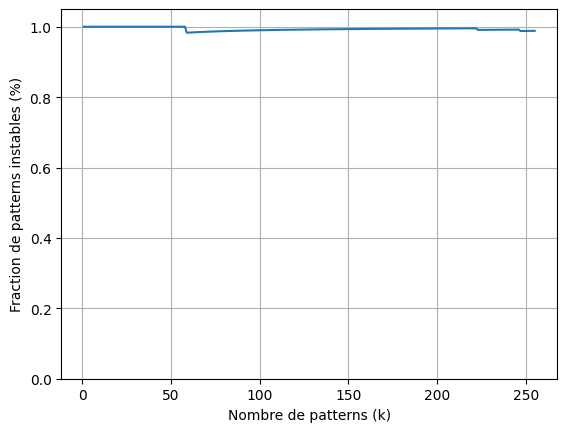

In [23]:
hopfield_network_modern_ImageNet_exp = HopfieldNetworkModern(16, f=lambda x: torch.exp(x), max_iter=10)
hopfield_network_modern_ImageNet_exp.benchmark(imageNet_16x16[:256])

On voit par contre que si la puissance est trop haute avec $x^{20}$ ou avec une énergie de la forme $e^x$, les performances du réseau se dégradent fortement. En effet, dans ces cas, le réseau ne parvient plus à mémoriser de patterns de manière stable. Cela montre qu'il existe une limite à l'augmentation de la puissance dans la fonction d'énergie pour améliorer les performances du réseau de Hopfield moderne.

Calcul de la stabilité sur le data set: 100%|██████████| 255/255 [01:42<00:00,  2.49it/s]


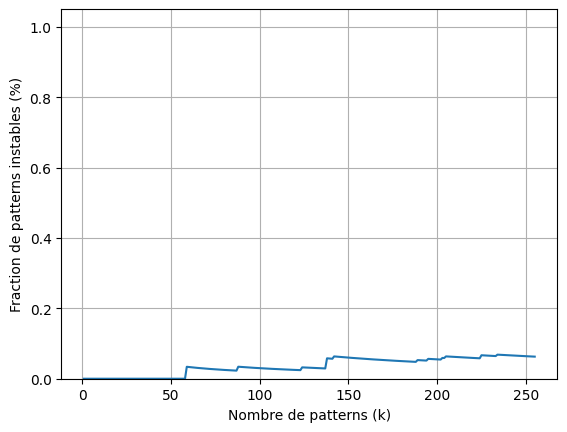

In [24]:
beta = 1.0 / ((16*16)**0.5)
hopfield_network_modern_ImageNet_exp2 = HopfieldNetworkModern(16, f=lambda x: torch.exp(x*beta), max_iter=10)
hopfield_network_modern_ImageNet_exp2.benchmark(imageNet_16x16[:256])

Ici on a normaliser les valeurs passées dans l'exponentielle pour éviter que les valeurs ne deviennent trop grandes, et on voit que les performances du réseau sont améliorées par rapport à l'énergie de la forme $e^x$. Les performances sont même meilleurs que celles obtenues avec une énergie de la forme $x^{10}$. On peut supposer que c'est la limite au delà de laquelle le réseaux devient instable car les valeurs deviennent trop petites.

## Résultats sur le dataset décorrélé

L'objectif est ici de tester l'efficacité du réseau de Hopfield moderne sur un jeu de données non corrélées, qui est le cas idéal pour ce type de réseau. Nous allons réaliser les mêmes benchmarks que pour le dataset ImageNet, mais cette fois avec des images générées aléatoirement et donc non corrélées entre elles.

In [21]:
non_correlee_1000 = torch.randint(0,2,[1000,16,16],dtype=torch.float,device=DEVICE)*2-1


--- Statistiques de corrélation ---
Max:                0.3120
Moyenne |corr|:     0.0498

--- Interprétation ---
Patterns TRÈS PEU CORRÉLÉS (quasi-aléatoires)


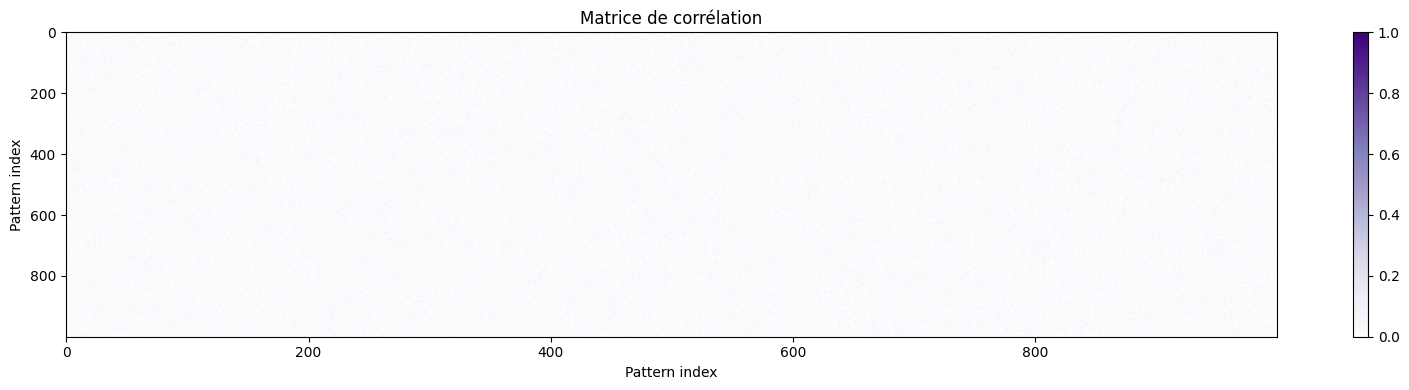

In [109]:
analyze_dataset_correlation(non_correlee_1000.reshape([-1,256]))

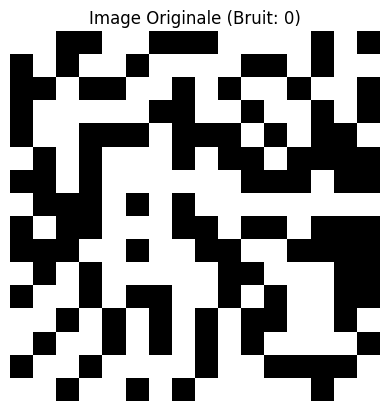

GIF sauvegardé sous hopfield.gif


In [24]:
random_image = bruitage_pixels_fixe(non_correlee_1000[0:1], 50)[0]
plt.imshow(non_correlee_1000[0].cpu().numpy(), cmap='gray')
plt.title("Image Originale (Bruit: 0)")
plt.axis('off') # Pour enlever les graduations
plt.show()

hopfield_network_modern_Noncorrelee_1000_2 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 2), max_iter=10, images=non_correlee_1000[:12])
result, trajectory, energies , cycle = hopfield_network_modern_Noncorrelee_1000_2.apply_with_trajectory(random_image)
trajectory = trajectory[0].cpu().reshape(-1,16,16).numpy()
energies_2_hopfield = energies[0].cpu().numpy()
make_gif_from_trajectory(trajectory, energies_2_hopfield, input_image=non_correlee_1000[0].cpu().numpy(), interval=50)

Calcul de la stabilité sur le data set: 100%|██████████| 199/199 [04:20<00:00,  1.31s/it]


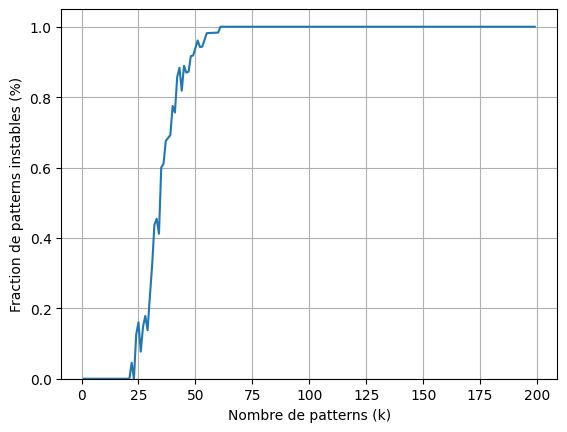

In [132]:
hopfield_network_modern_Noncorrelee_1000_2 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 2), max_iter=10)
hopfield_network_modern_Noncorrelee_1000_2.benchmark(non_correlee_1000[:200])

Analyse Robustesse (Vectorisée):  49%|████▉     | 98/198 [02:32<02:34,  1.54s/it]

k=100 : 15 versions bruitées par pattern (Essais: 1 | Batch Total: 1500)


Analyse Robustesse (Vectorisée): 100%|██████████| 198/198 [05:16<00:00,  1.60s/it]


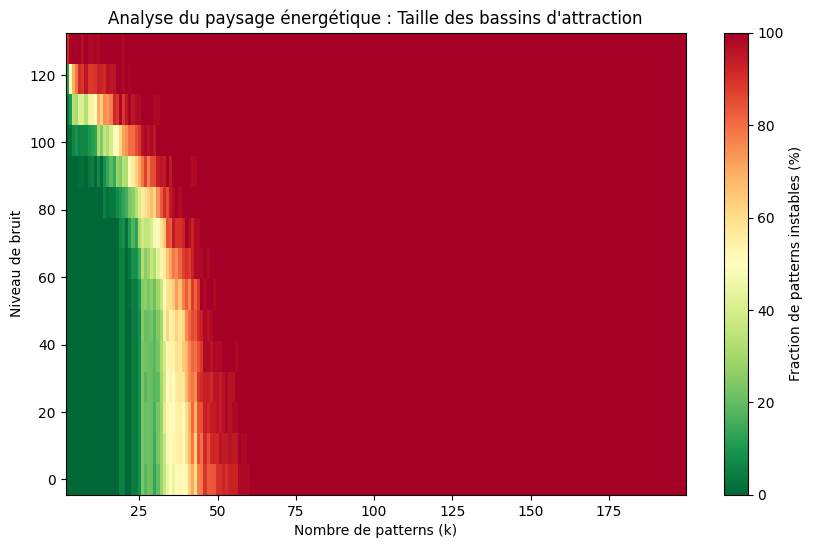

In [29]:
hopfield_network_modern_Noncorrelee_1000_2.benchmark_noise_robustness(non_correlee_1000[:200])

Taille globale du batch : 5000 ops
Résolution    : 128 niveaux de bruit


Progression (K): 100%|██████████| 199/199 [06:11<00:00,  1.87s/it]


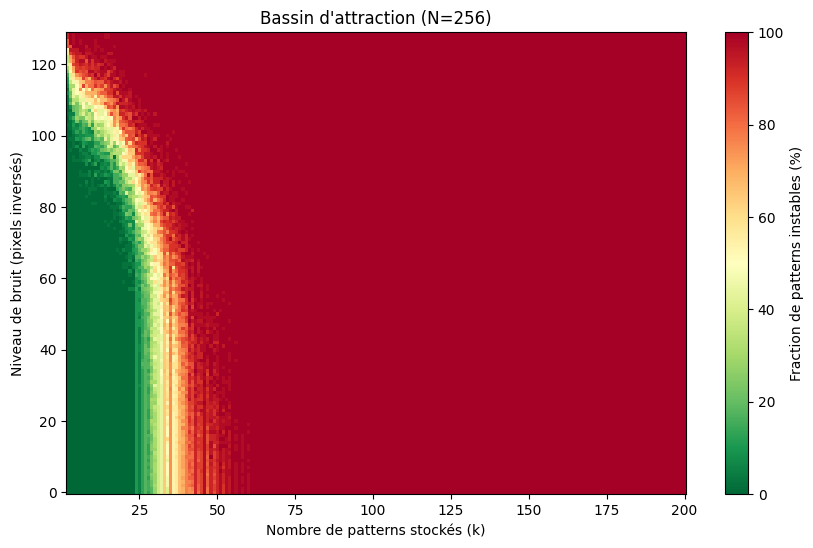

In [141]:
hopfield_network_modern_Noncorrelee_1000_2 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 2), max_iter=10)

hopfield_network_modern_Noncorrelee_1000_2.benchmark_noise_robustness(non_correlee_1000[:200], noise_step=128 ,k_start=2, k_end=200, noise_start=0, noise_end=128, max_size_batch=5000, vectorized_mode=True, k_step=1)

Analyse Robustesse (Vectorisée): 100%|██████████| 48/48 [01:19<00:00,  1.65s/it]


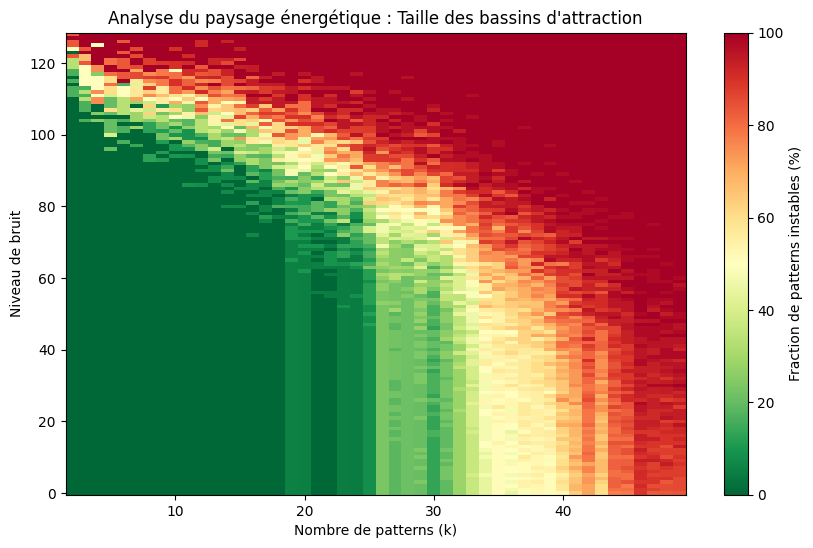

In [24]:
hopfield_network_modern_Noncorrelee_1000_2.benchmark_noise_robustness(non_correlee_1000[:50], noise_step=129)

Calcul de la stabilité sur le data set: 100%|██████████| 199/199 [00:30<00:00,  6.43it/s]


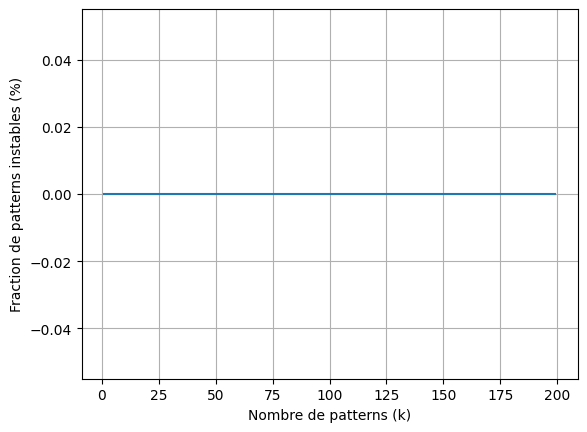

In [131]:
hopfield_network_modern_Noncorrelee_1000_5 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 5), max_iter=10)
hopfield_network_modern_Noncorrelee_1000_5.benchmark(non_correlee_1000[:200])

Analyse Robustesse (Vectorisée):  49%|████▉     | 98/198 [02:28<02:33,  1.54s/it]

k=100 : 15 versions bruitées par pattern (Essais: 1 | Batch Total: 1500)


Analyse Robustesse (Vectorisée): 100%|██████████| 198/198 [05:13<00:00,  1.58s/it]


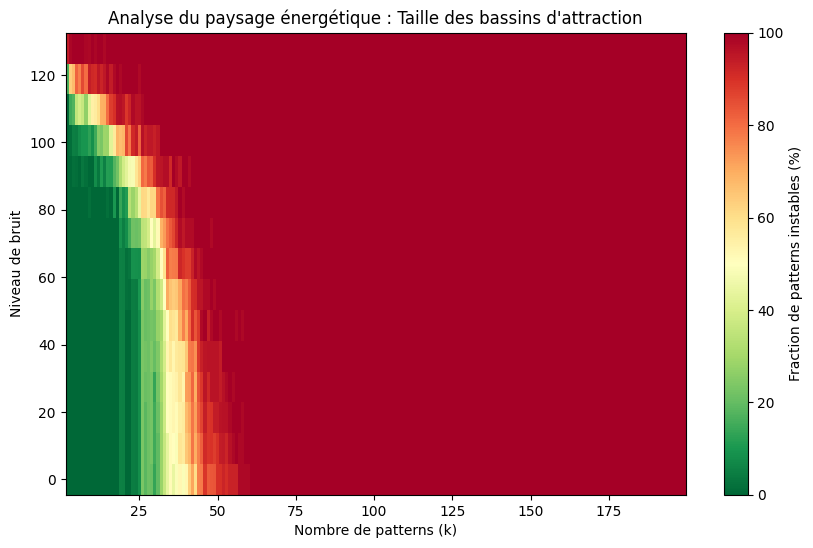

In [31]:
hopfield_network_modern_Noncorrelee_1000_2.benchmark_noise_robustness(non_correlee_1000[:200], noise_step=1 ,k_start=2, k_end=200, noise_start=0, noise_end=128, max_size_batch=5000, vectorized_mode=True, k_step=1)

Analyse Robustesse (Vectorisée): 100%|██████████| 48/48 [00:30<00:00,  1.56it/s]


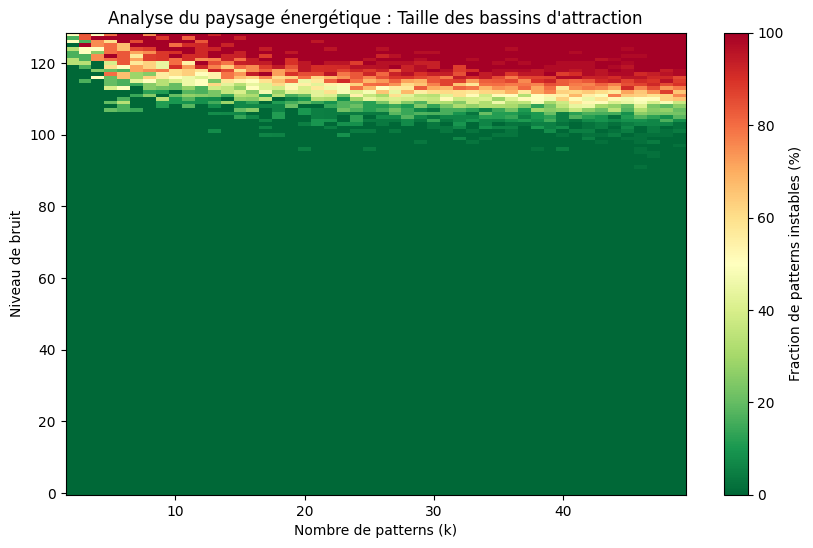

In [26]:
hopfield_network_modern_Noncorrelee_1000_5.benchmark_noise_robustness(non_correlee_1000[:50], noise_step=129)

Calcul de la stabilité sur le data set: 100%|██████████| 999/999 [03:44<00:00,  4.46it/s]


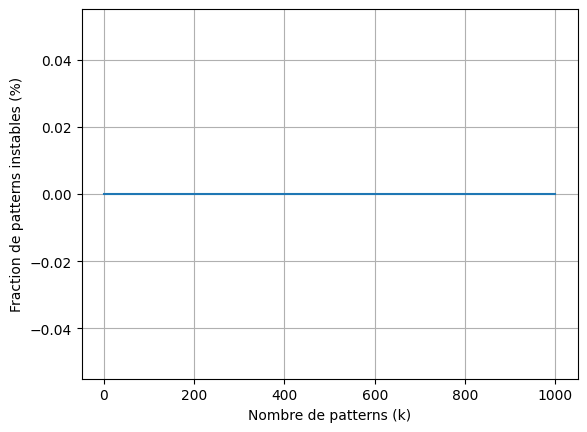

In [26]:
hopfield_network_modern_Noncorrelee_1000_10 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 10), max_iter=10, images=non_correlee_1000)
hopfield_network_modern_Noncorrelee_1000_10.benchmark(non_correlee_1000)

Analyse Robustesse (Vectorisée):  49%|████▉     | 98/198 [00:58<00:56,  1.76it/s]

k=100 : 15 versions bruitées par pattern (Essais: 1 | Batch Total: 1500)


Analyse Robustesse (Vectorisée): 100%|██████████| 198/198 [01:58<00:00,  1.67it/s]


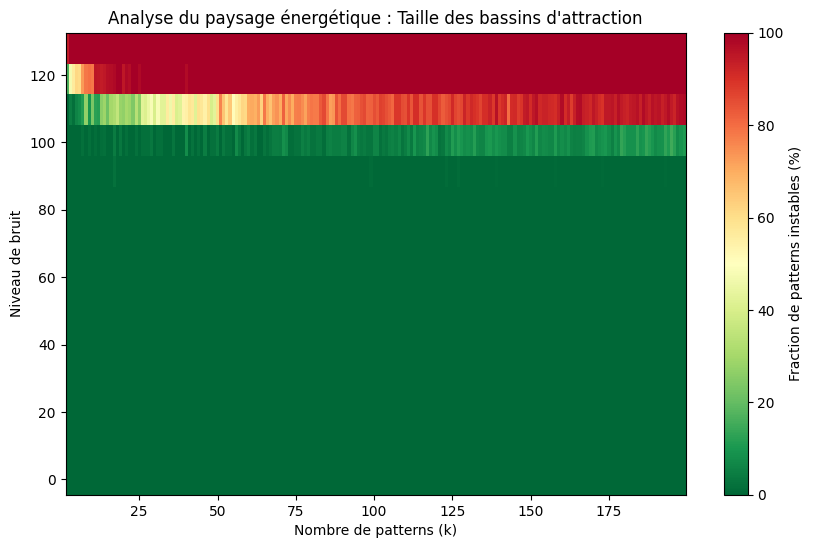

In [38]:
hopfield_network_modern_Noncorrelee_1000_10.benchmark_noise_robustness(non_correlee_1000[:200])

Analyse Robustesse (Vectorisée): 100%|██████████| 48/48 [00:29<00:00,  1.60it/s]


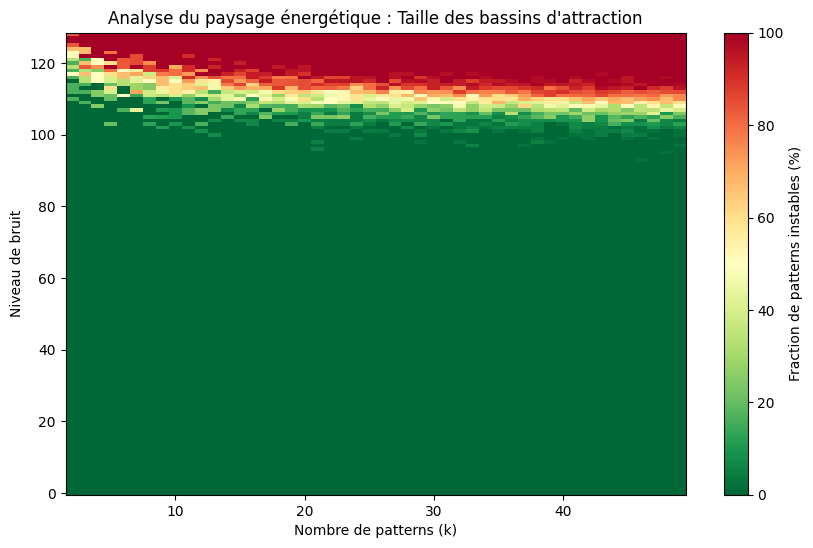

In [25]:
hopfield_network_modern_Noncorrelee_1000_10.benchmark_noise_robustness(non_correlee_1000[:50], noise_step=129)

In [13]:
non_correlee_20000 = torch.randint(0,2,[20000,16,16],dtype=torch.float,device=DEVICE)*2-1

In [89]:
hopfield_network_modern_Noncorrelee_20000_5 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 5), max_iter=10)

Calcul de la stabilité sur le data set: 100%|██████████| 4/4 [08:34<00:00, 128.68s/it]


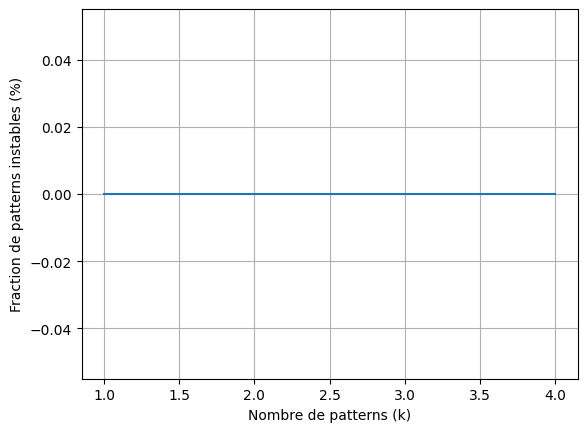

In [21]:
hopfield_network_modern_Noncorrelee_20000_5.benchmark(non_correlee_20000[:20000], train=True, k_step=2000)

Taille globale du batch : 2000 ops
Résolution    : 15 niveaux de bruit


Progression (K): 100%|██████████| 250/250 [14:22<00:00,  3.45s/it]


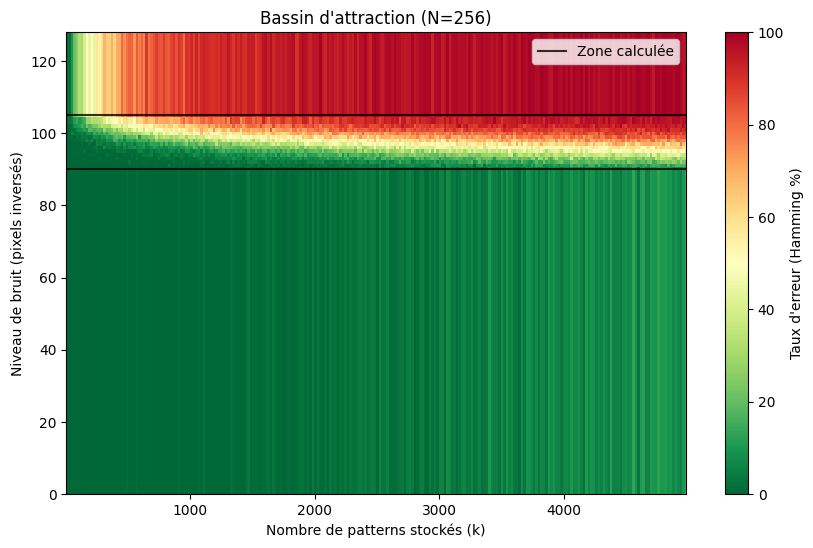

In [25]:
hopfield_network_modern_Noncorrelee_20000_5.benchmark_noise_robustness(non_correlee_20000, k_start=2, k_end=5000, k_step=20, noise_start=90, noise_end=105, max_size_batch=2000, vectorized_mode=True)

Taille globale du batch : 2000 ops
Résolution    : 15 niveaux de bruit


Progression (K): 100%|██████████| 250/250 [10:28<00:00,  2.52s/it]


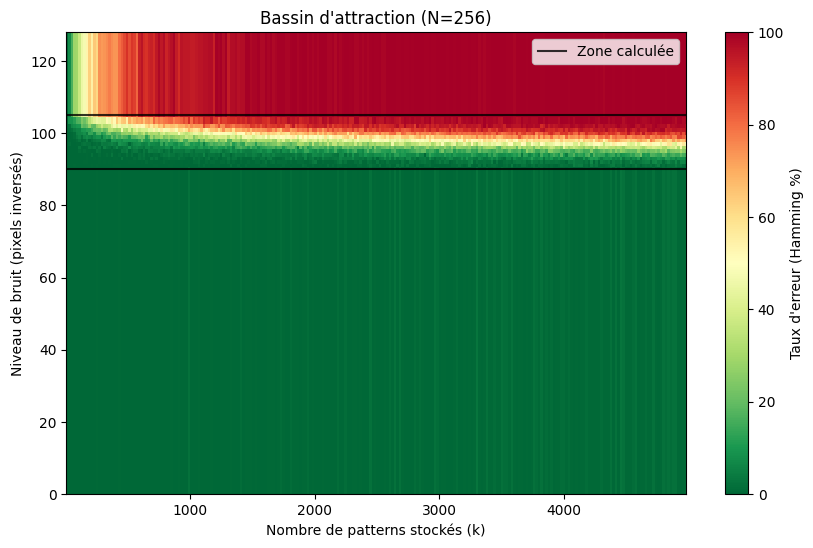

In [26]:
hopfield_network_modern_Noncorrelee_20000_10 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 10), max_iter=10)
hopfield_network_modern_Noncorrelee_20000_10.benchmark_noise_robustness(non_correlee_20000, k_start=2, k_end=5000, k_step=20, noise_start=90, noise_end=105, max_size_batch=2000, vectorized_mode=True)

Taille globale du batch : 2000 ops
Résolution    : 15 niveaux de bruit


Progression (K): 100%|██████████| 250/250 [17:39<00:00,  4.24s/it]


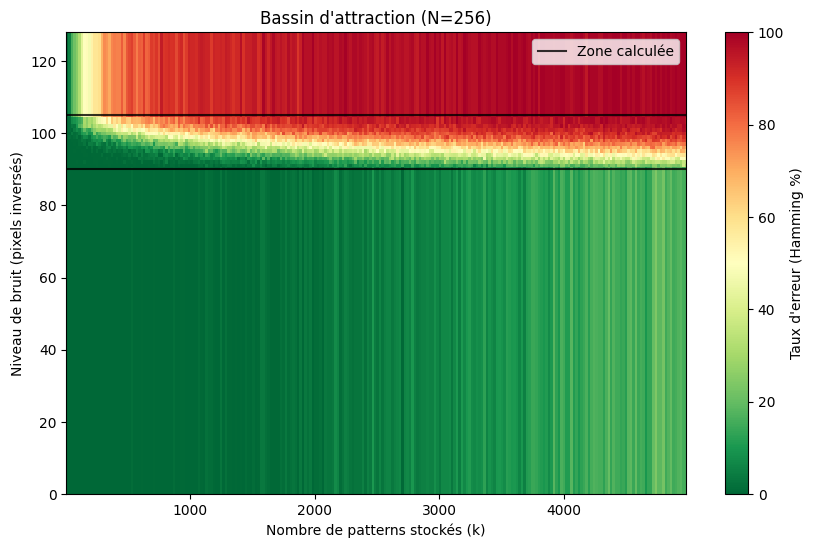

In [27]:
hopfield_network_modern_Noncorrelee_20000_exp = HopfieldNetworkModern(16, f=lambda x: torch.exp(x * 1 / ((16*16)**0.5)), max_iter=10)
hopfield_network_modern_Noncorrelee_20000_exp.benchmark_noise_robustness(non_correlee_20000, k_start=2, k_end=5000, k_step=20, noise_start=90, noise_end=105, max_size_batch=2000, vectorized_mode=True)

Taille globale du batch : 2000 ops
Résolution    : 15 niveaux de bruit


Progression (K): 100%|██████████| 41/41 [10:52<00:00, 15.92s/it]


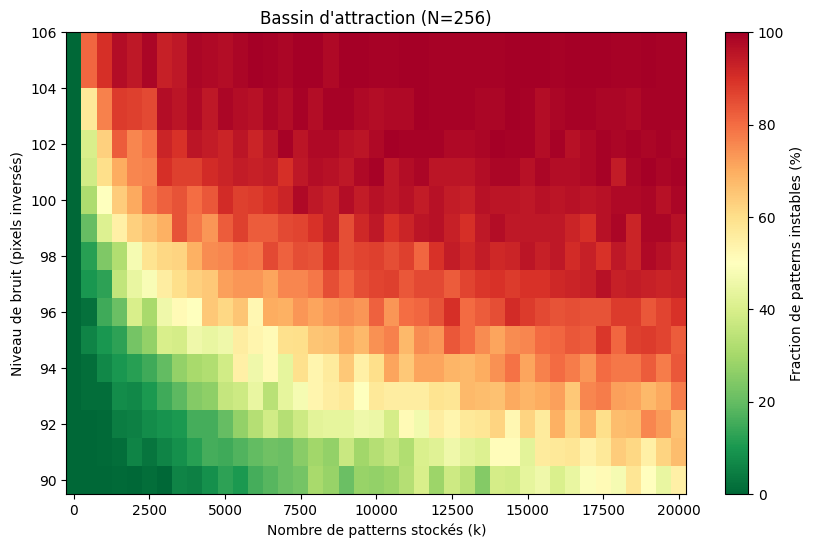

In [91]:
hopfield_network_modern_Noncorrelee_20000_5.benchmark_noise_robustness(non_correlee_20000, k_start=2, k_end=20000, k_step=500, noise_start=90, noise_end=105, max_size_batch=2000, vectorized_mode=True)

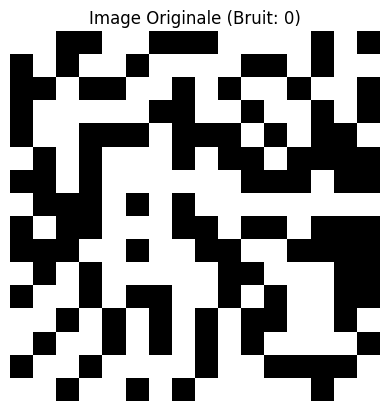

GIF sauvegardé sous hopfield2.gif


In [17]:
random_image = bruitage_pixels_fixe(non_correlee_1000[0:1], 110)[0]
plt.imshow(non_correlee_1000[0].cpu().numpy(), cmap='gray')
plt.title("Image Originale (Bruit: 0)")
plt.axis('off') # Pour enlever les graduations
plt.show()

hopfield_network_modern_Noncorrelee_1000_10 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 10), max_iter=10, images=non_correlee_1000[:12])
result, trajectory, energies , cycle = hopfield_network_modern_Noncorrelee_1000_10.apply_with_trajectory(random_image)
trajectory = trajectory[0].cpu().reshape(-1,16,16).numpy()
energies_10_hopfield = energies[0].cpu().numpy()
make_gif_from_trajectory(trajectory, energies_10_hopfield, input_image=non_correlee_1000[0].cpu().numpy(), interval=50, filename="hopfield2.gif")

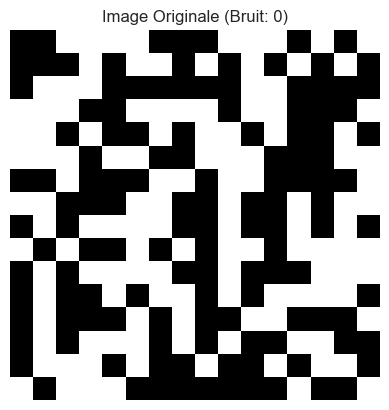

GIF sauvegardé sous hopfield3.gif


In [49]:
random_image = bruitage_pixels_fixe(non_correlee_1000[0:1], 256)[0]
plt.imshow(bruitage_pixels_fixe(non_correlee_1000[0:1], 256)[0].reshape([16,16]).cpu().numpy(), cmap='gray')
plt.title("Image Originale (Bruit: 0)")
plt.axis('off') # Pour enlever les graduations
plt.show()

hopfield_network_modern_Noncorrelee_1000_10 = HopfieldNetworkModern(16, f=lambda x: torch.pow(x, 10), max_iter=10, images=non_correlee_1000)
result, trajectory, energies , cycle = hopfield_network_modern_Noncorrelee_1000_10.apply_with_trajectory(random_image)
trajectory = trajectory[0].cpu().reshape(-1,16,16).numpy()
energies = energies[0].cpu().numpy()
make_gif_from_trajectory(trajectory, energies, input_image=non_correlee_1000[0].cpu().numpy(), interval=50, filename="hopfield3.gif")

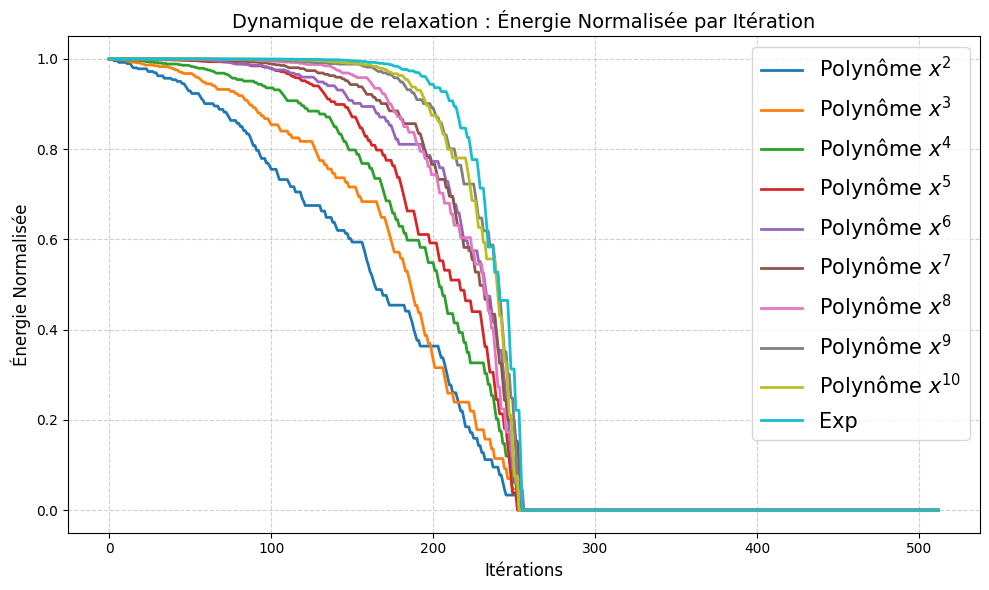

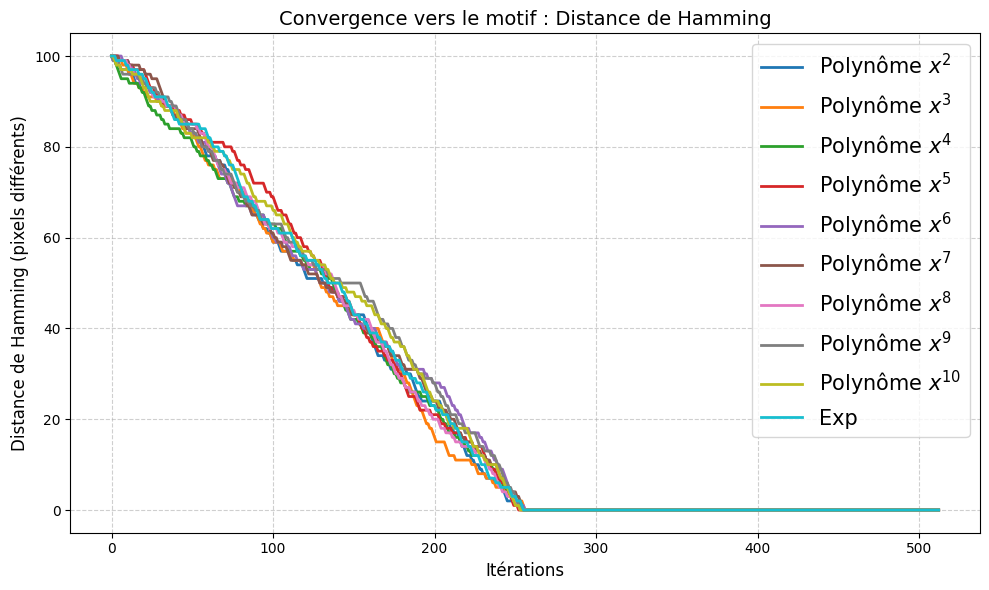

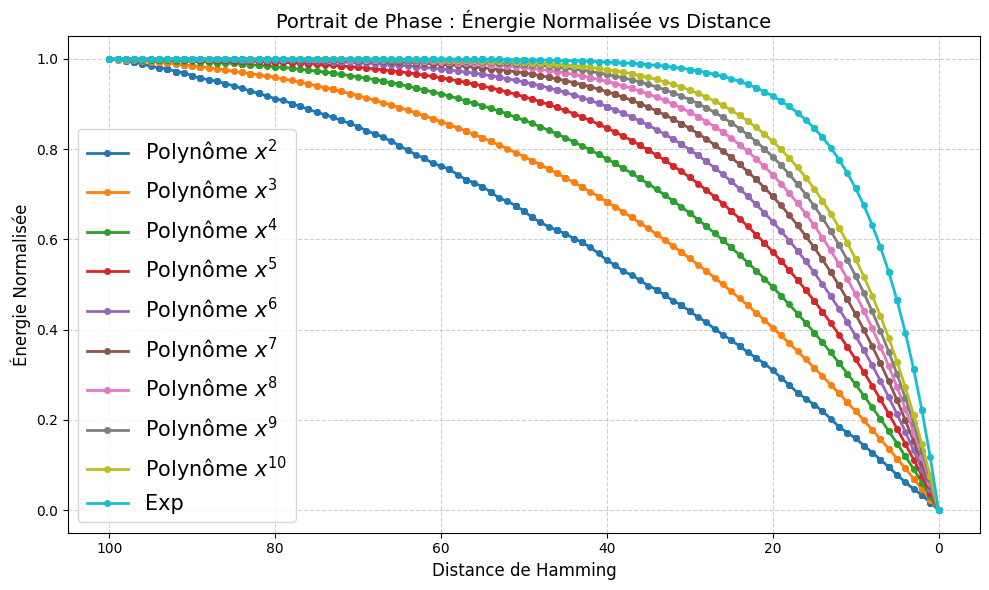

In [27]:
def normalize_energies(energies):
    E_min = np.min(energies)
    E_max = np.max(energies)
    if E_max - E_min == 0:
        return np.zeros_like(energies)
    return (energies - E_min) / (E_max - E_min)

def get_label_and_style(key):
    cmap = cm.get_cmap('tab10')
    
    if key == 'exp':
        return 'Exp', cmap(10)
    
    try:
        k = int(key.split("_")[1])
        label = f'Polynôme $x^{{{k}}}$' 
        color = cmap(k-2)
        return label, color
    
    except:
        return key, 'black'

def run_simulation(update_func, image_start, ref_images, max_iter=10):   
    network = HopfieldNetworkModern(16, f=update_func, max_iter=max_iter, images=ref_images)
    result, trajectory, energies, cycle = network.apply_with_trajectory(image_start)
    dists = distance_hamming(trajectory.reshape(-1, 16, 16), ref_images)[:, 0]
    energies_val = energies[0].cpu().numpy()
    return energies_val, dists

def plot_generic(data_dict, x_type, y_type, title, ylabel, invert_x=False):
    plt.figure(figsize=(10, 6))
    plt.title(title, fontsize=14)
    plt.ylabel(ylabel, fontsize=12)
    
    xlabel_map = {
        'iter': "Itérations",
        'dist': "Distance de Hamming",
        'energy': "Énergie Normalisée"
    }
    plt.xlabel(xlabel_map.get(x_type, x_type), fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    if invert_x:
        plt.gca().invert_xaxis()

    for key, (energies, dists) in data_dict.items():
        norm_energies = normalize_energies(energies)
        y_data = dists if y_type == 'dist' else norm_energies
        
        if x_type == 'iter':
            x_data = range(len(y_data))
        elif x_type == 'dist':
            x_data = dists
        else: 
            x_data = norm_energies

        label, color = get_label_and_style(key)
        
        marker = 'o' if x_type != 'iter' else None 
        markersize = 4 if x_type != 'iter' else None
        
        plt.plot(x_data, y_data, label=label, color=color, 
                 linewidth=2, marker=marker, markersize=markersize)

    plt.legend(loc='upper right' if not invert_x else 'best', fontsize=15)
    plt.tight_layout()
    plt.show()


dataset_size = 5
beta = 1.0 / ((16*16)**0.5)
random_image = bruitage_pixels_fixe(non_correlee_1000[0:1], 100)[0]
values = {}

for k in range(2, 11):
    energies_poly, dists_poly = run_simulation(
        update_func=lambda x: torch.pow(x, k),
        image_start=random_image,
        ref_images=non_correlee_1000[:dataset_size]
    )
    values[f"puissance_{k}"] = (energies_poly, dists_poly.cpu().numpy())

energies_exp, dists_exp = run_simulation(
    update_func=lambda x: torch.exp(x * beta),
    image_start=random_image,
    ref_images=non_correlee_1000[:dataset_size]
)
values["exp"] = (energies_exp, dists_exp.cpu().numpy())

plot_generic(
    values, 
    x_type='iter', 
    y_type='energy',
    title="Dynamique de relaxation : Énergie Normalisée par Itération",
    ylabel="Énergie Normalisée"
)

plot_generic(
    values, 
    x_type='iter', 
    y_type='dist',
    title="Convergence vers le motif : Distance de Hamming",
    ylabel="Distance de Hamming (pixels différents)"
)

plot_generic(
    values, 
    x_type='dist', 
    y_type='energy',
    title="Portrait de Phase : Énergie Normalisée vs Distance",
    ylabel="Énergie Normalisée",
    invert_x=True
)

Simulation Modèle Classique (x^2)...


Simulation: 100%|██████████| 128/128 [00:41<00:00,  3.09it/s]


Simulation Modèle Moderne (x^10)...


Simulation: 100%|██████████| 128/128 [00:47<00:00,  2.70it/s]


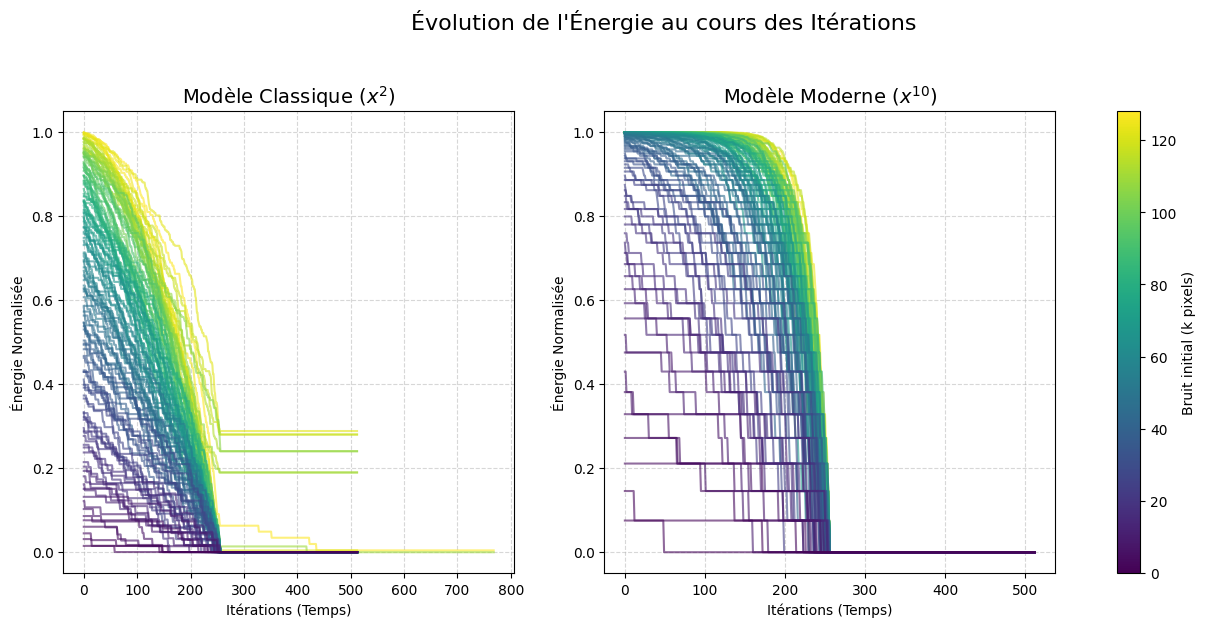

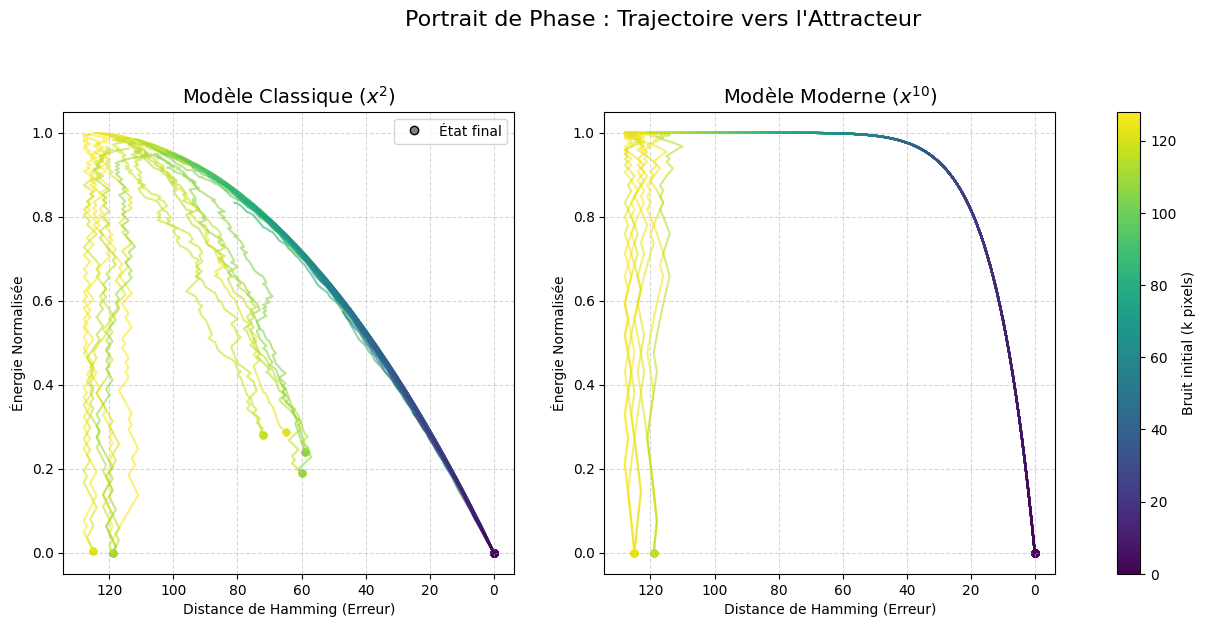

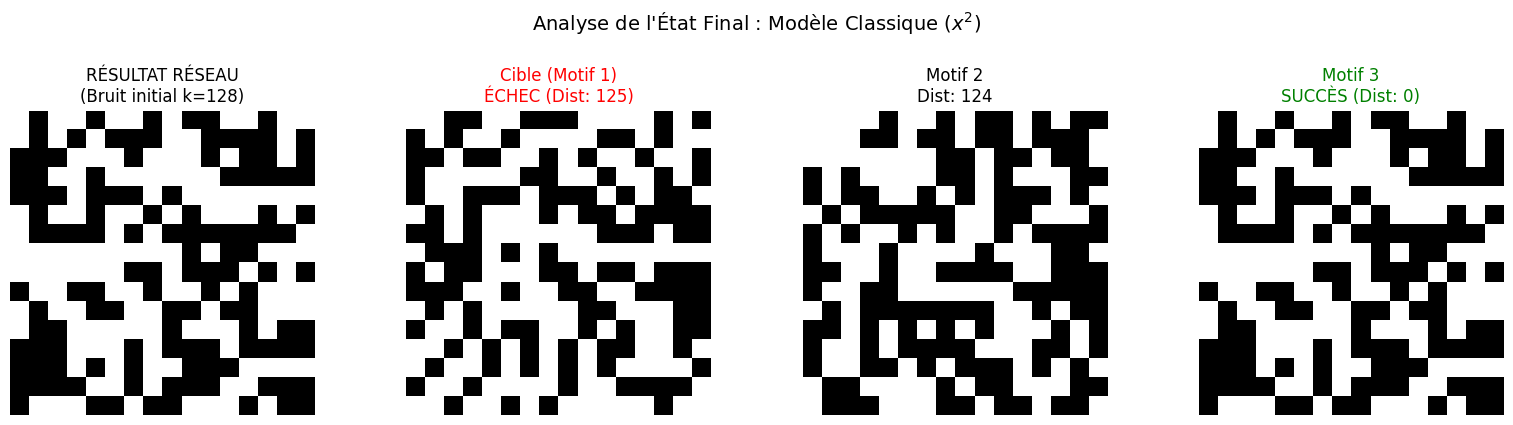

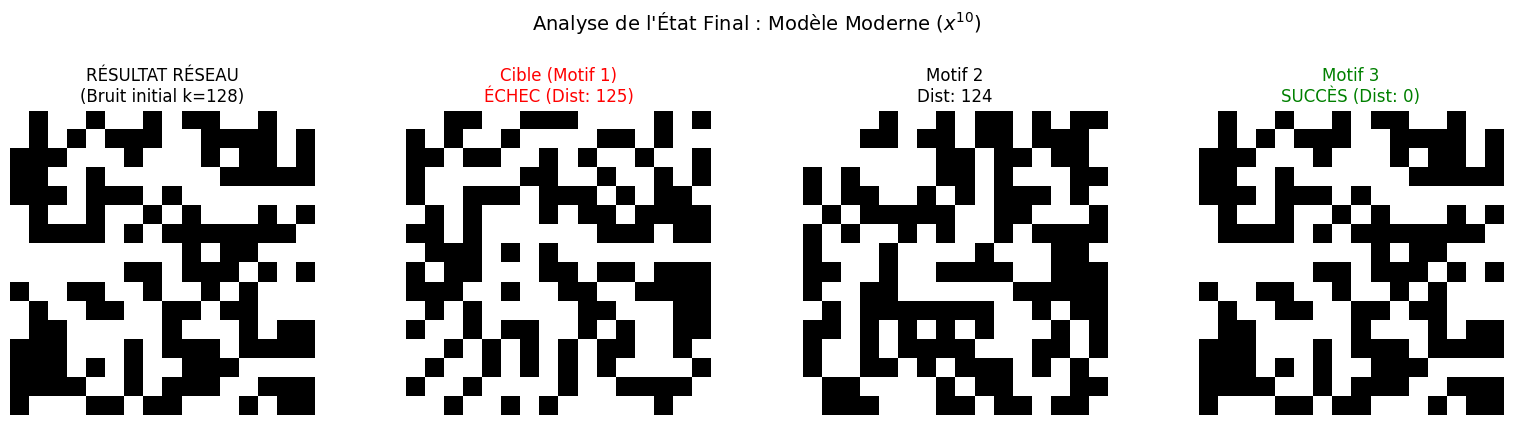

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
from tqdm import tqdm

def run_hopfield_simulation(steps, update_function, base_image, ref_images):
    results = []
    target_images = ref_images 
    
    for k in tqdm(steps, desc="Simulation"):
        random_image = bruitage_pixels_fixe(base_image, int(k))[0]
        network = HopfieldNetworkModern(16, f=update_function, max_iter=10, images=ref_images)
        result, trajectory, energies, cycle = network.apply_with_trajectory(random_image)
        dists = distance_hamming(trajectory.reshape(-1, 16, 16), target_images)[:, 0]
        results.append((dists, energies[0].cpu().numpy(), k, result.detach().cpu()))
        
    return results

steps_range = np.linspace(1, 128, 128)
base_img = non_correlee_1000[0:1]
ref_imgs = non_correlee_1000[:3]

print("Simulation Modèle Classique (x^2)...")
data_x2 = run_hopfield_simulation(steps_range, lambda x: torch.pow(x, 2), base_img, ref_imgs)
print("Simulation Modèle Moderne (x^10)...")
data_x10 = run_hopfield_simulation(steps_range, lambda x: torch.pow(x, 10), base_img, ref_imgs)

experiments = [(data_x2, r"Modèle Classique ($x^2$)", lambda x: torch.pow(x, 2)),(data_x10, r"Modèle Moderne ($x^{10}$)", lambda x: torch.pow(x, 10))]

cmap = cm.get_cmap('viridis')

fig1, axes_time = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle("Évolution de l'Énergie au cours des Itérations", fontsize=16, y=1.05)

for col_idx, (data, title_base, _) in enumerate(experiments):
    ax = axes_time[col_idx]
    
    all_e = np.concatenate([run[1] for run in data])
    e_min, e_max = np.min(all_e), np.max(all_e)
    e_range = (e_max - e_min) if e_max != e_min else 1
    
    ax.set_title(title_base, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    for _, energies, k, _ in sorted(data, key=lambda x: x[2], reverse=True):
        color = cmap(k / 128.0)
        ax.plot((energies - e_min) / e_range, color=color, alpha=0.6)
        
    ax.set_xlabel("Itérations (Temps)")
    ax.set_ylabel("Énergie Normalisée")

sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=128))
fig1.colorbar(sm1, ax=axes_time.tolist(), label='Bruit initial (k pixels)')
plt.show()

fig2, axes_phase = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle("Portrait de Phase : Trajectoire vers l'Attracteur", fontsize=16, y=1.05)

for col_idx, (data, title_base, _) in enumerate(experiments):
    ax = axes_phase[col_idx]
    
    all_e = np.concatenate([run[1] for run in data])
    e_min, e_max = np.min(all_e), np.max(all_e)
    e_range = (e_max - e_min) if e_max != e_min else 1
    
    ax.set_title(title_base, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    for dists, energies, k, _ in sorted(data, key=lambda x: x[2], reverse=True):
        color = cmap(k / 128.0)
        e_norm = (energies - e_min) / e_range
        dists_val = dists.cpu() if torch.is_tensor(dists) else dists
        
        ax.plot(dists_val, e_norm, color=color, alpha=0.6)
        ax.scatter(dists_val[-1], e_norm[-1], color=color, s=30, linewidths=0.5)
        
    ax.set_xlabel("Distance de Hamming (Erreur)")
    ax.set_ylabel("Énergie Normalisée")
    ax.invert_xaxis() 

final_point = mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markeredgecolor='black', label='État final')
axes_phase[0].legend(handles=[final_point])

sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=128))
fig2.colorbar(sm2, ax=axes_phase.tolist(), label='Bruit initial (k pixels)')
plt.show()

k_max_idx = -1 
num_refs = len(ref_imgs)

for data, title_base, update_func in experiments:
    _, _, k_val, final_res_tensor = data[k_max_idx]

    final_state_np = final_res_tensor.squeeze().numpy() # Déjà sur CPU grâce au .cpu() dans la fonction
    final_state_tensor_for_dist = final_res_tensor.reshape(1, 16, 16)

    fig, axes = plt.subplots(1, num_refs + 1, figsize=(4 * (num_refs + 1), 4))
    fig.suptitle(f"Analyse de l'État Final : {title_base}", fontsize=14, y=1.05)

    axes[0].imshow(final_state_np, cmap='gray')
    axes[0].set_title(f"RÉSULTAT RÉSEAU\n(Bruit initial k={int(k_val)})")
    axes[0].axis('off')

    for i in range(num_refs):
        ref_img_np = ref_imgs[i].squeeze().cpu().numpy()
        ref_img_tensor = ref_imgs[i:i+1]
        
        d_hamming = distance_hamming(final_state_tensor_for_dist, ref_img_tensor).item()
        axes[i+1].imshow(ref_img_np, cmap='gray')
        if i == 0:
            axes[i+1].set_title(f"Cible (Motif {i+1})\nÉCHEC (Dist: {d_hamming:.0f})", color='red')
        elif d_hamming == 0:
             axes[i+1].set_title(f"Motif {i+1}\nSUCCÈS (Dist: {d_hamming:.0f})", color='green')
        else:
            axes[i+1].set_title(f"Motif {i+1}\nDist: {d_hamming:.0f}", color='black')
                
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()